In [42]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/home/users/alessandro.ruzza/.fonts/urw-base35-fonts-master/fonts/palr45w.ttf'  # wherever you put it
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

# LaTeX pt to inches: 1 pt = 1/72.27 inch
textwidth_pt = 345.0  # <-- replace with YOUR \the\textwidth value
textwidth_in = textwidth_pt / 72.27

fig_width = textwidth_in          # full text width
fig_height = fig_width * 0.75     # adjust aspect ratio to taste (0.618 for golden ratio)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Palatino", "Palatino Linotype", "URW Palladio L", "serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 10,          # base size — everything inherits from this
    "axes.labelsize": 10,
    "xtick.labelsize": 8,     # slightly smaller for ticks is common practice
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 500,
})


# Quantification of the emulator uncertainty directly on channel maps of the training set

In [3]:
import os
os.chdir("/exa/projects/DiscEvol_storage/alessandro.ruzza/fforge/UnetEmu/fforge/evaluation/")

In [43]:
import h5py
import numpy as np
import pandas as pd

#training set
emu_train_cmaps = h5py.File("cmaps_emulations_small_alltraining.h5", "r")
#emu_train_cmaps['emu_true_para'].refresh()
simu_train_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like3corr_train.npy')
params = pd.read_csv('../data/data/data/gas_tri_256/run4.csv')
params_test = pd.read_csv('../data/data/data/gas_tri_256/testpara.csv')

#computing error
emucmaps = emu_train_cmaps['emu_true_para'][:]
err = (emu_train_cmaps['emu_true_para']-simu_train_cmaps)

#testset
simu_test_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like3corr.npy')[:, 42:64]
emu_test_cmaps = h5py.File('cmaps_emulations_small_SIMPARAN.h5')['emu_true_para']
emu_test_cmaps.refresh()
err_test = (emu_test_cmaps-simu_test_cmaps)

(np.float64(-0.5), np.float64(249.5), np.float64(249.5), np.float64(-0.5))

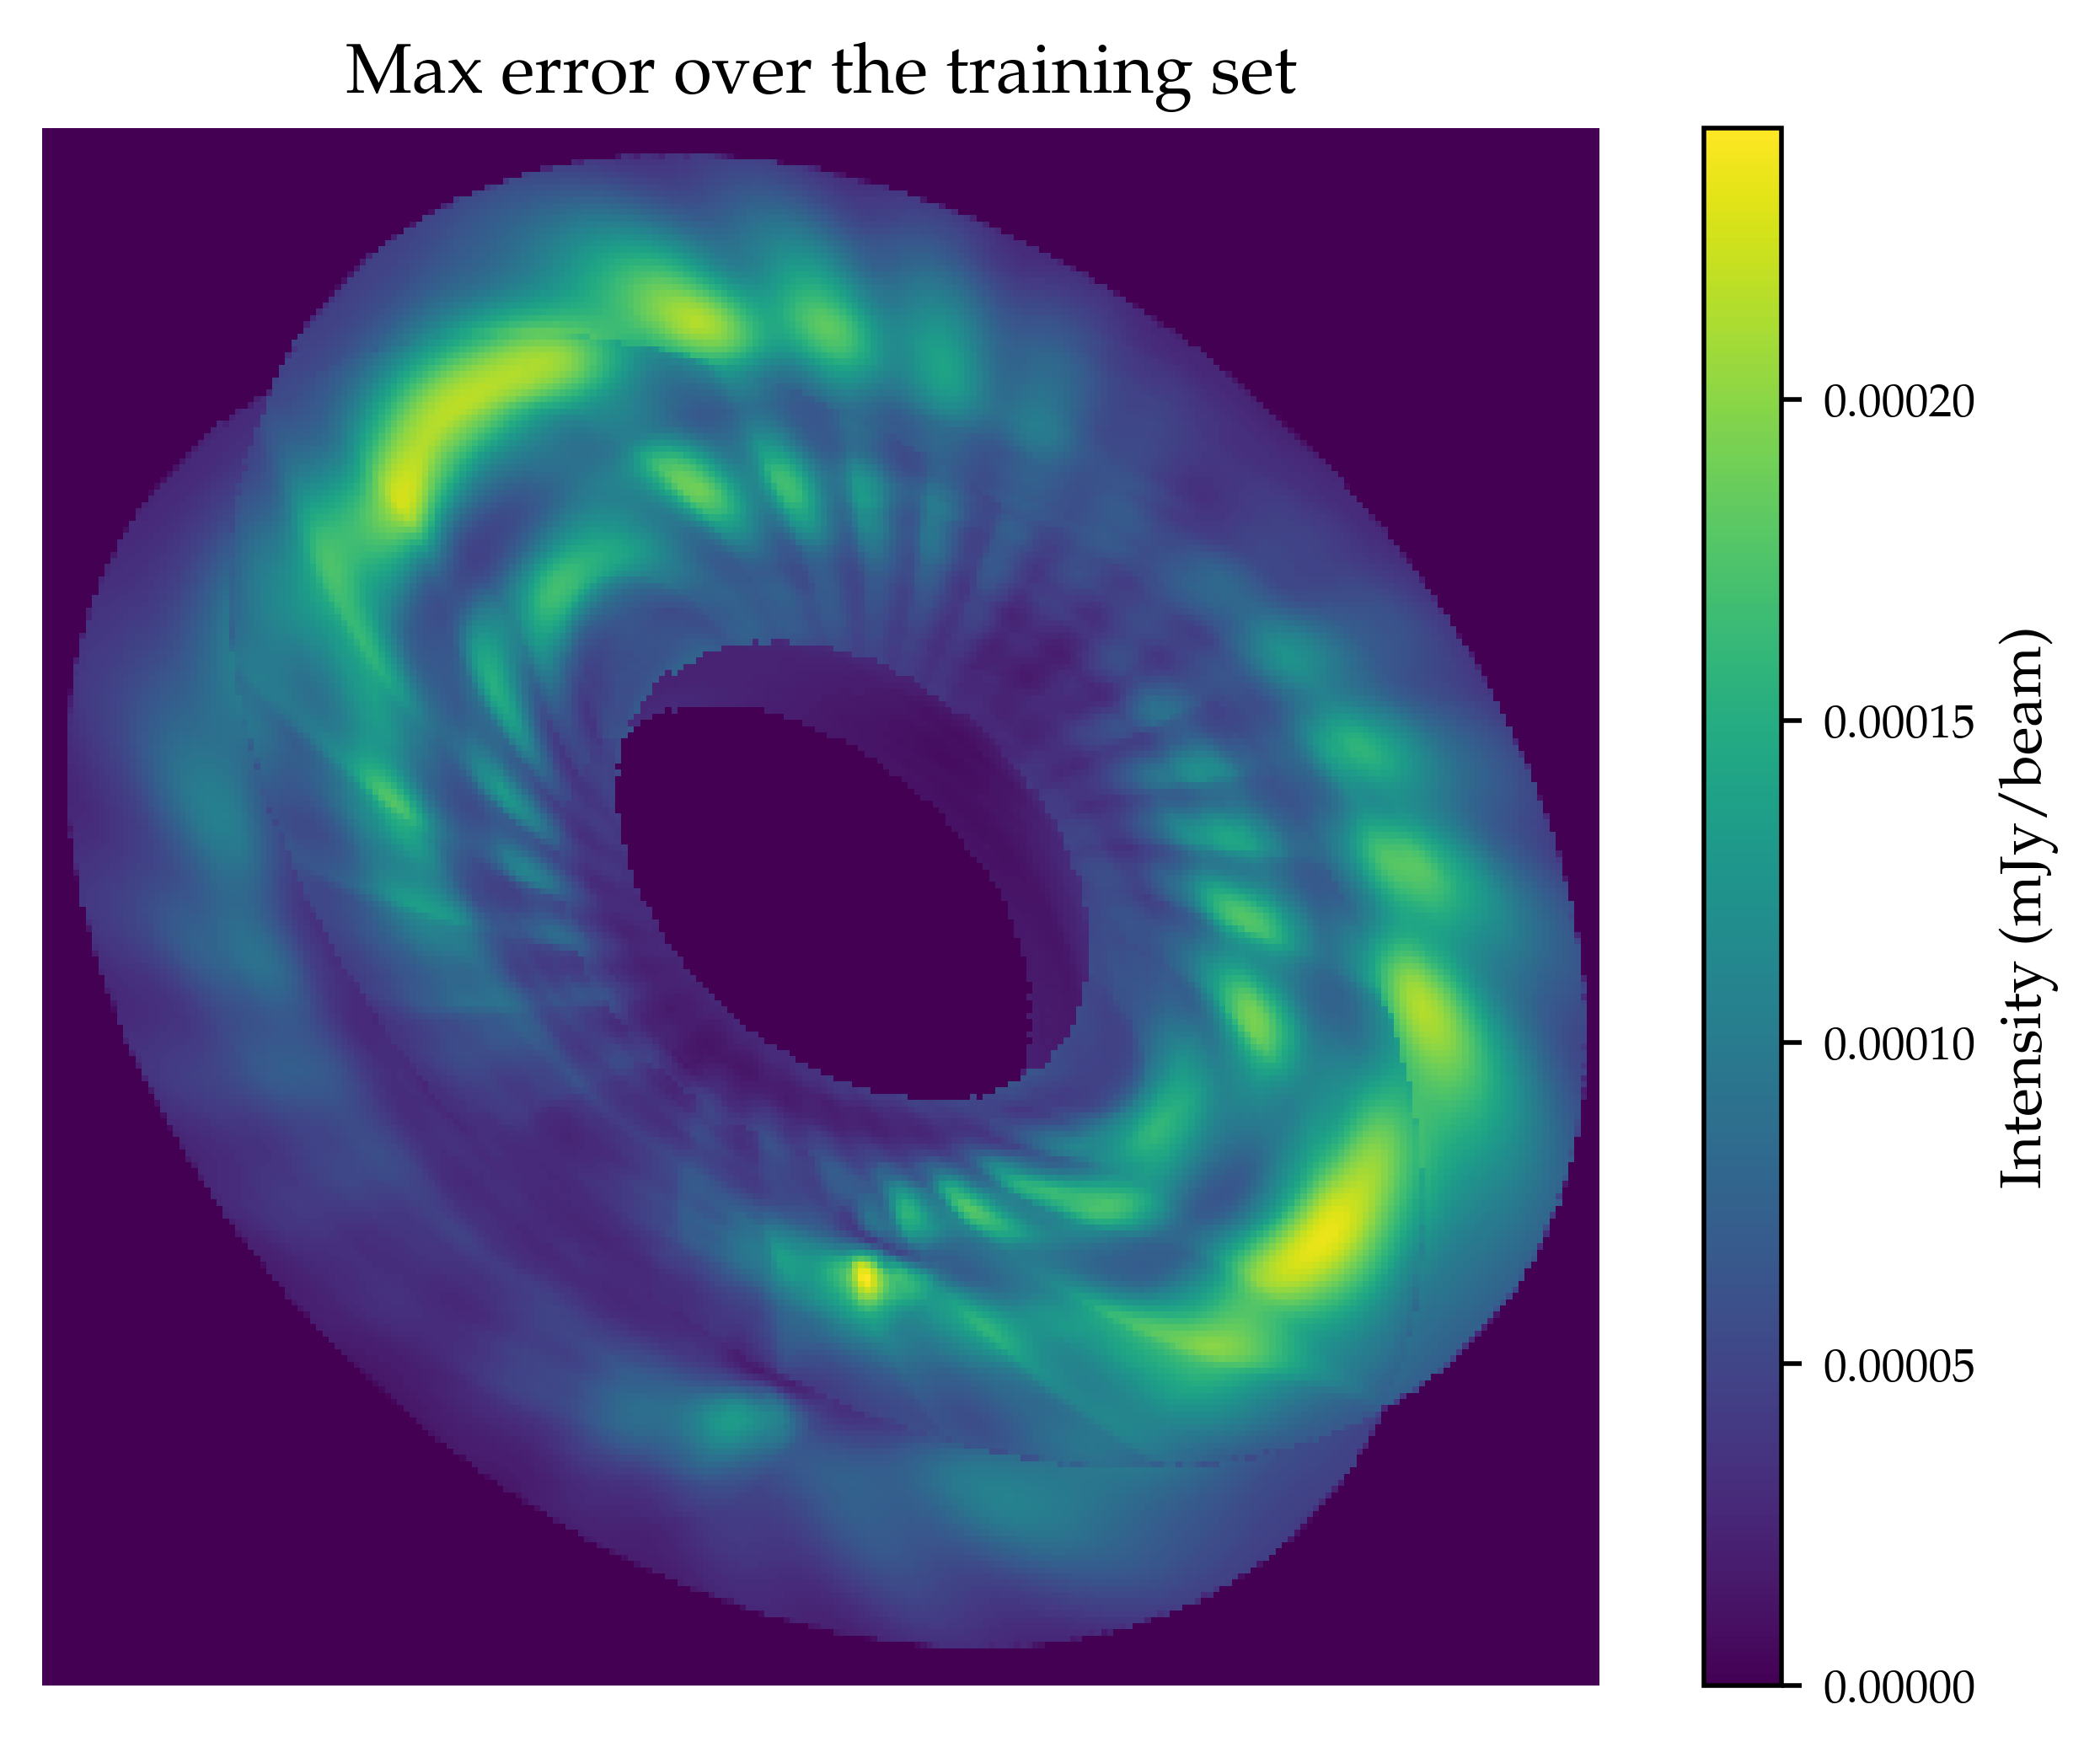

In [44]:
import matplotlib.pyplot as plt
plt.imshow(np.mean(np.abs(err_test), axis=(0,1)))
plt.colorbar(label='Intensity (mJy/beam)')
plt.title('Max error over the training set')
plt.axis('off')

In [45]:
emulator_error = np.nan_to_num(np.sqrt((err**2).sum(axis=(1,2,3))/np.sum(simu_train_cmaps>1.e-3, axis=(1,2,3))))
emulator_error_test = np.nan_to_num(np.sqrt((err_test**2).sum(axis=(1,2,3))/np.sum(simu_test_cmaps>1e-3, axis=(1,2,3))))

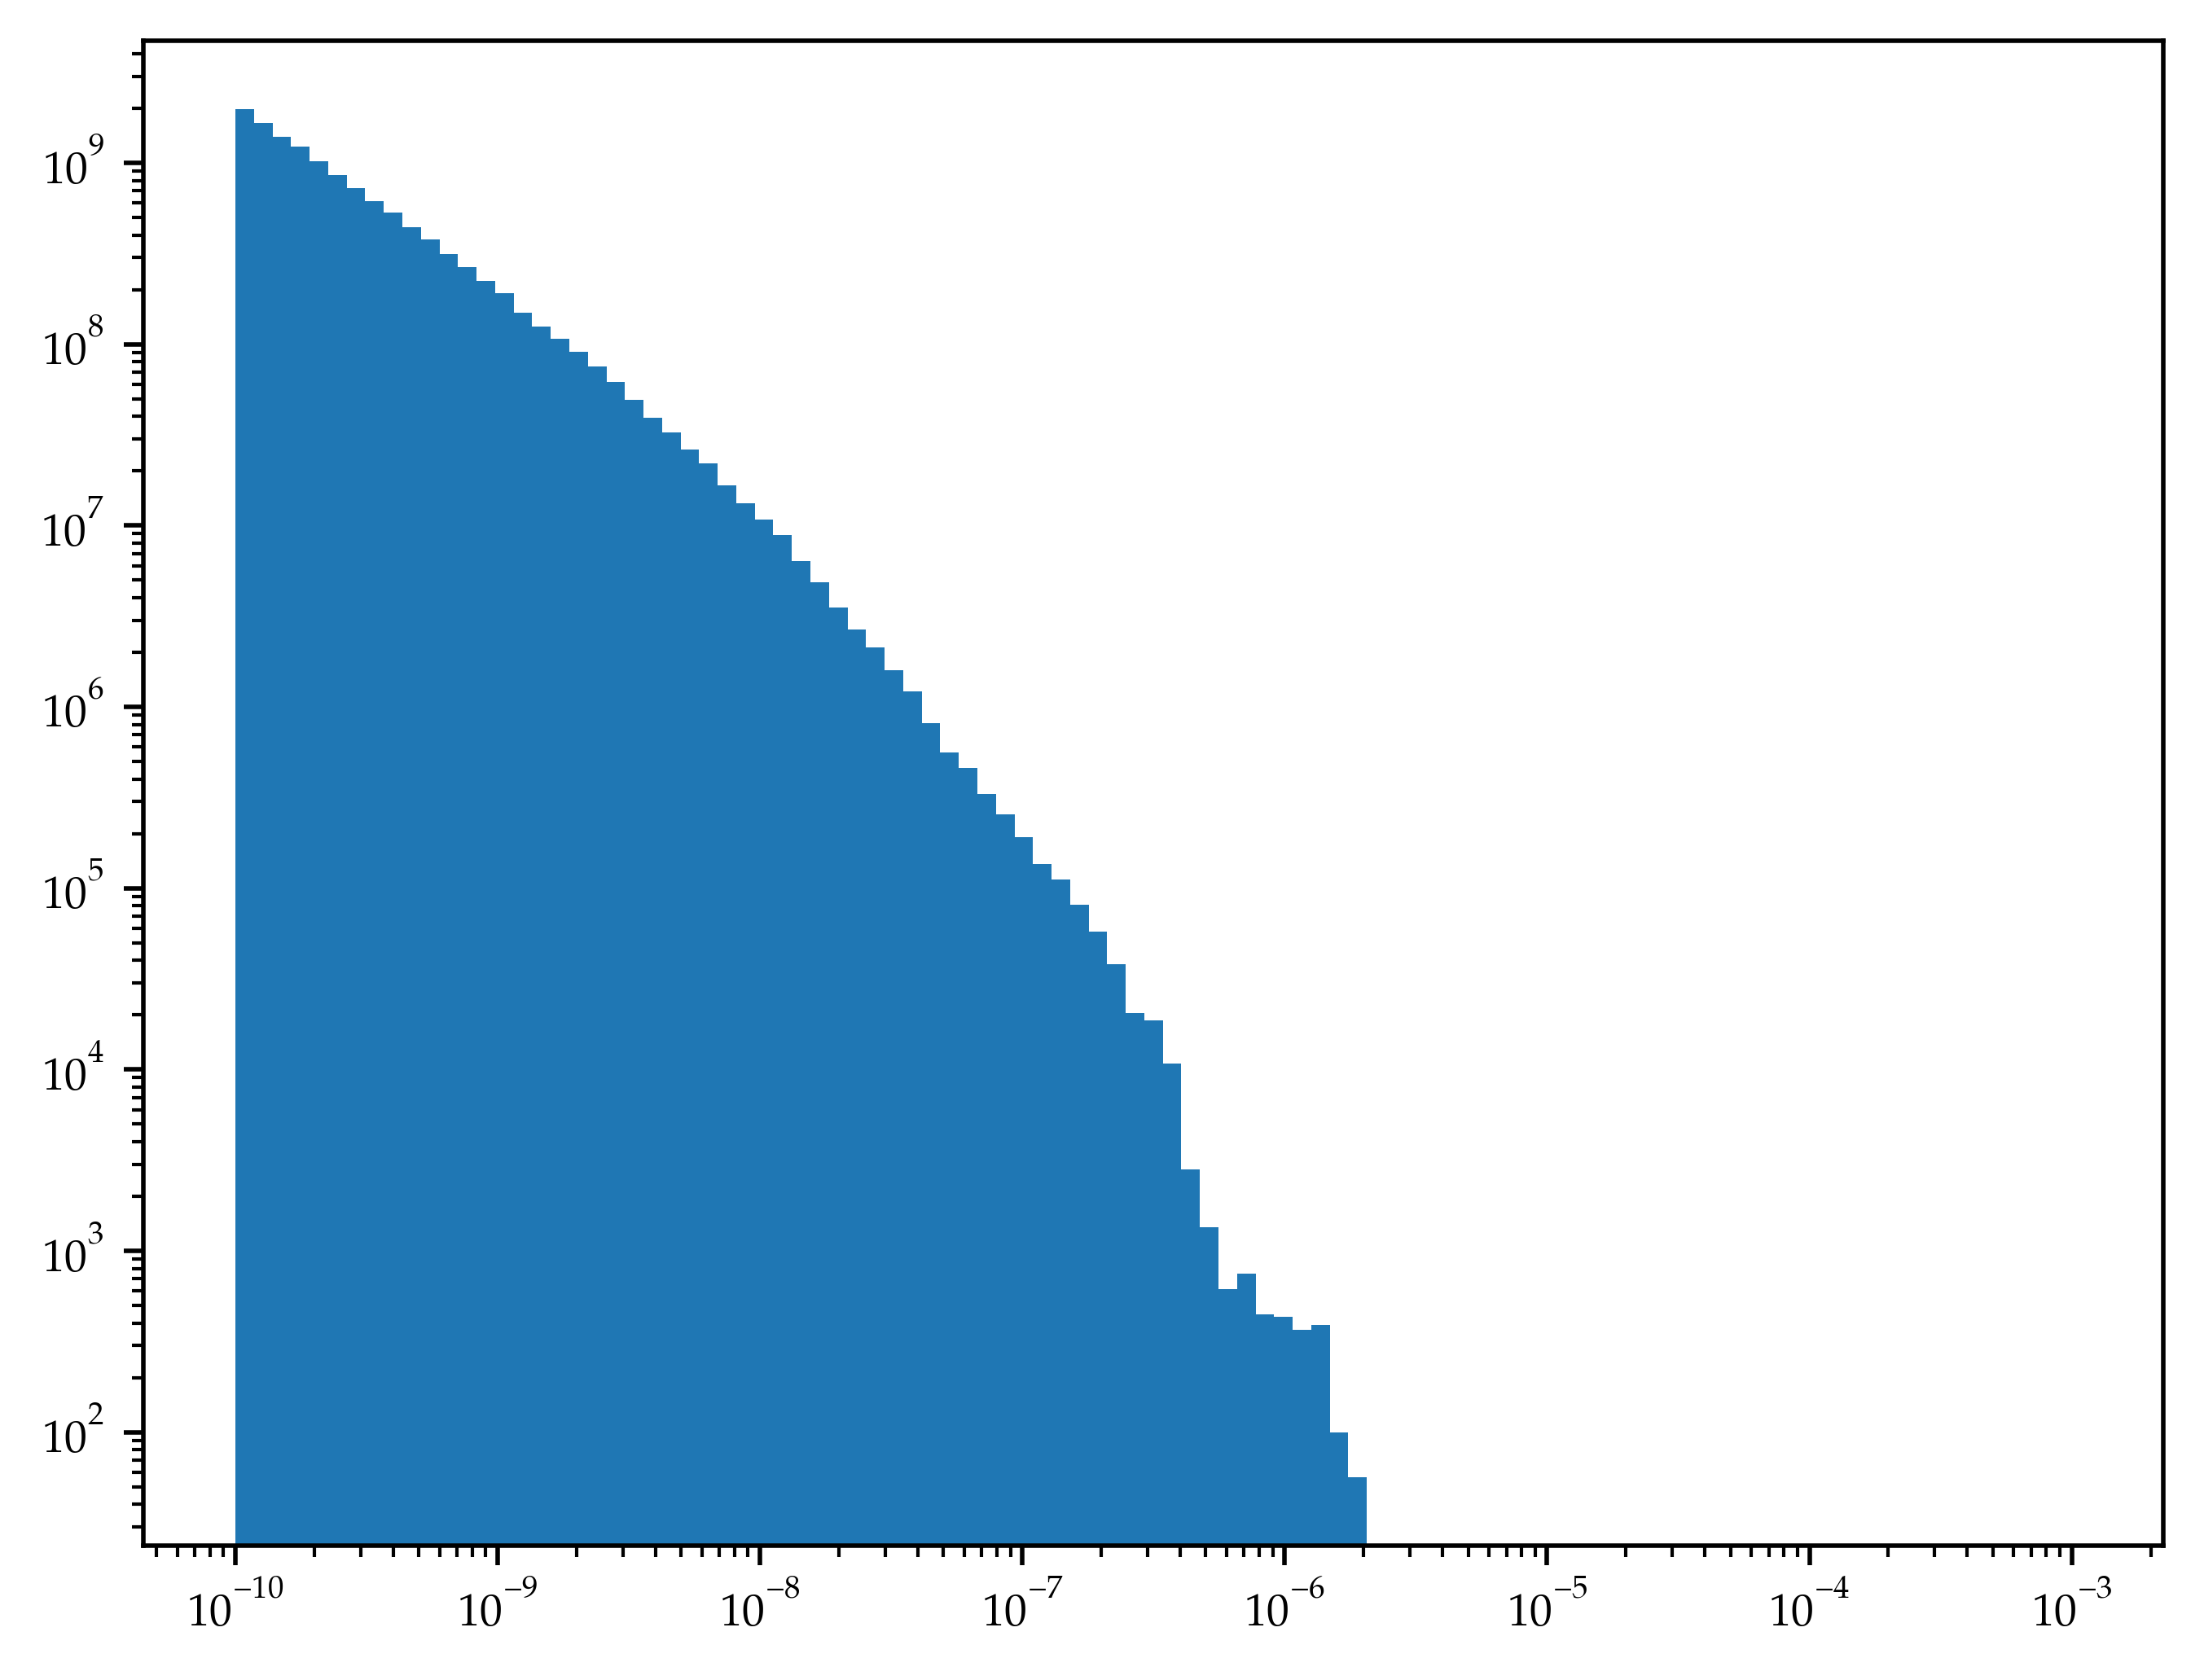

In [46]:
plt.hist((err**2)[0].ravel(), bins=np.logspace(-10, -3, 100), density=True)
plt.xscale('log')
plt.yscale('log')

In [47]:
np.median(emulator_error)

np.float64(0.00027209322365507997)

Fit:  y = 10^-1.094 x^0.727


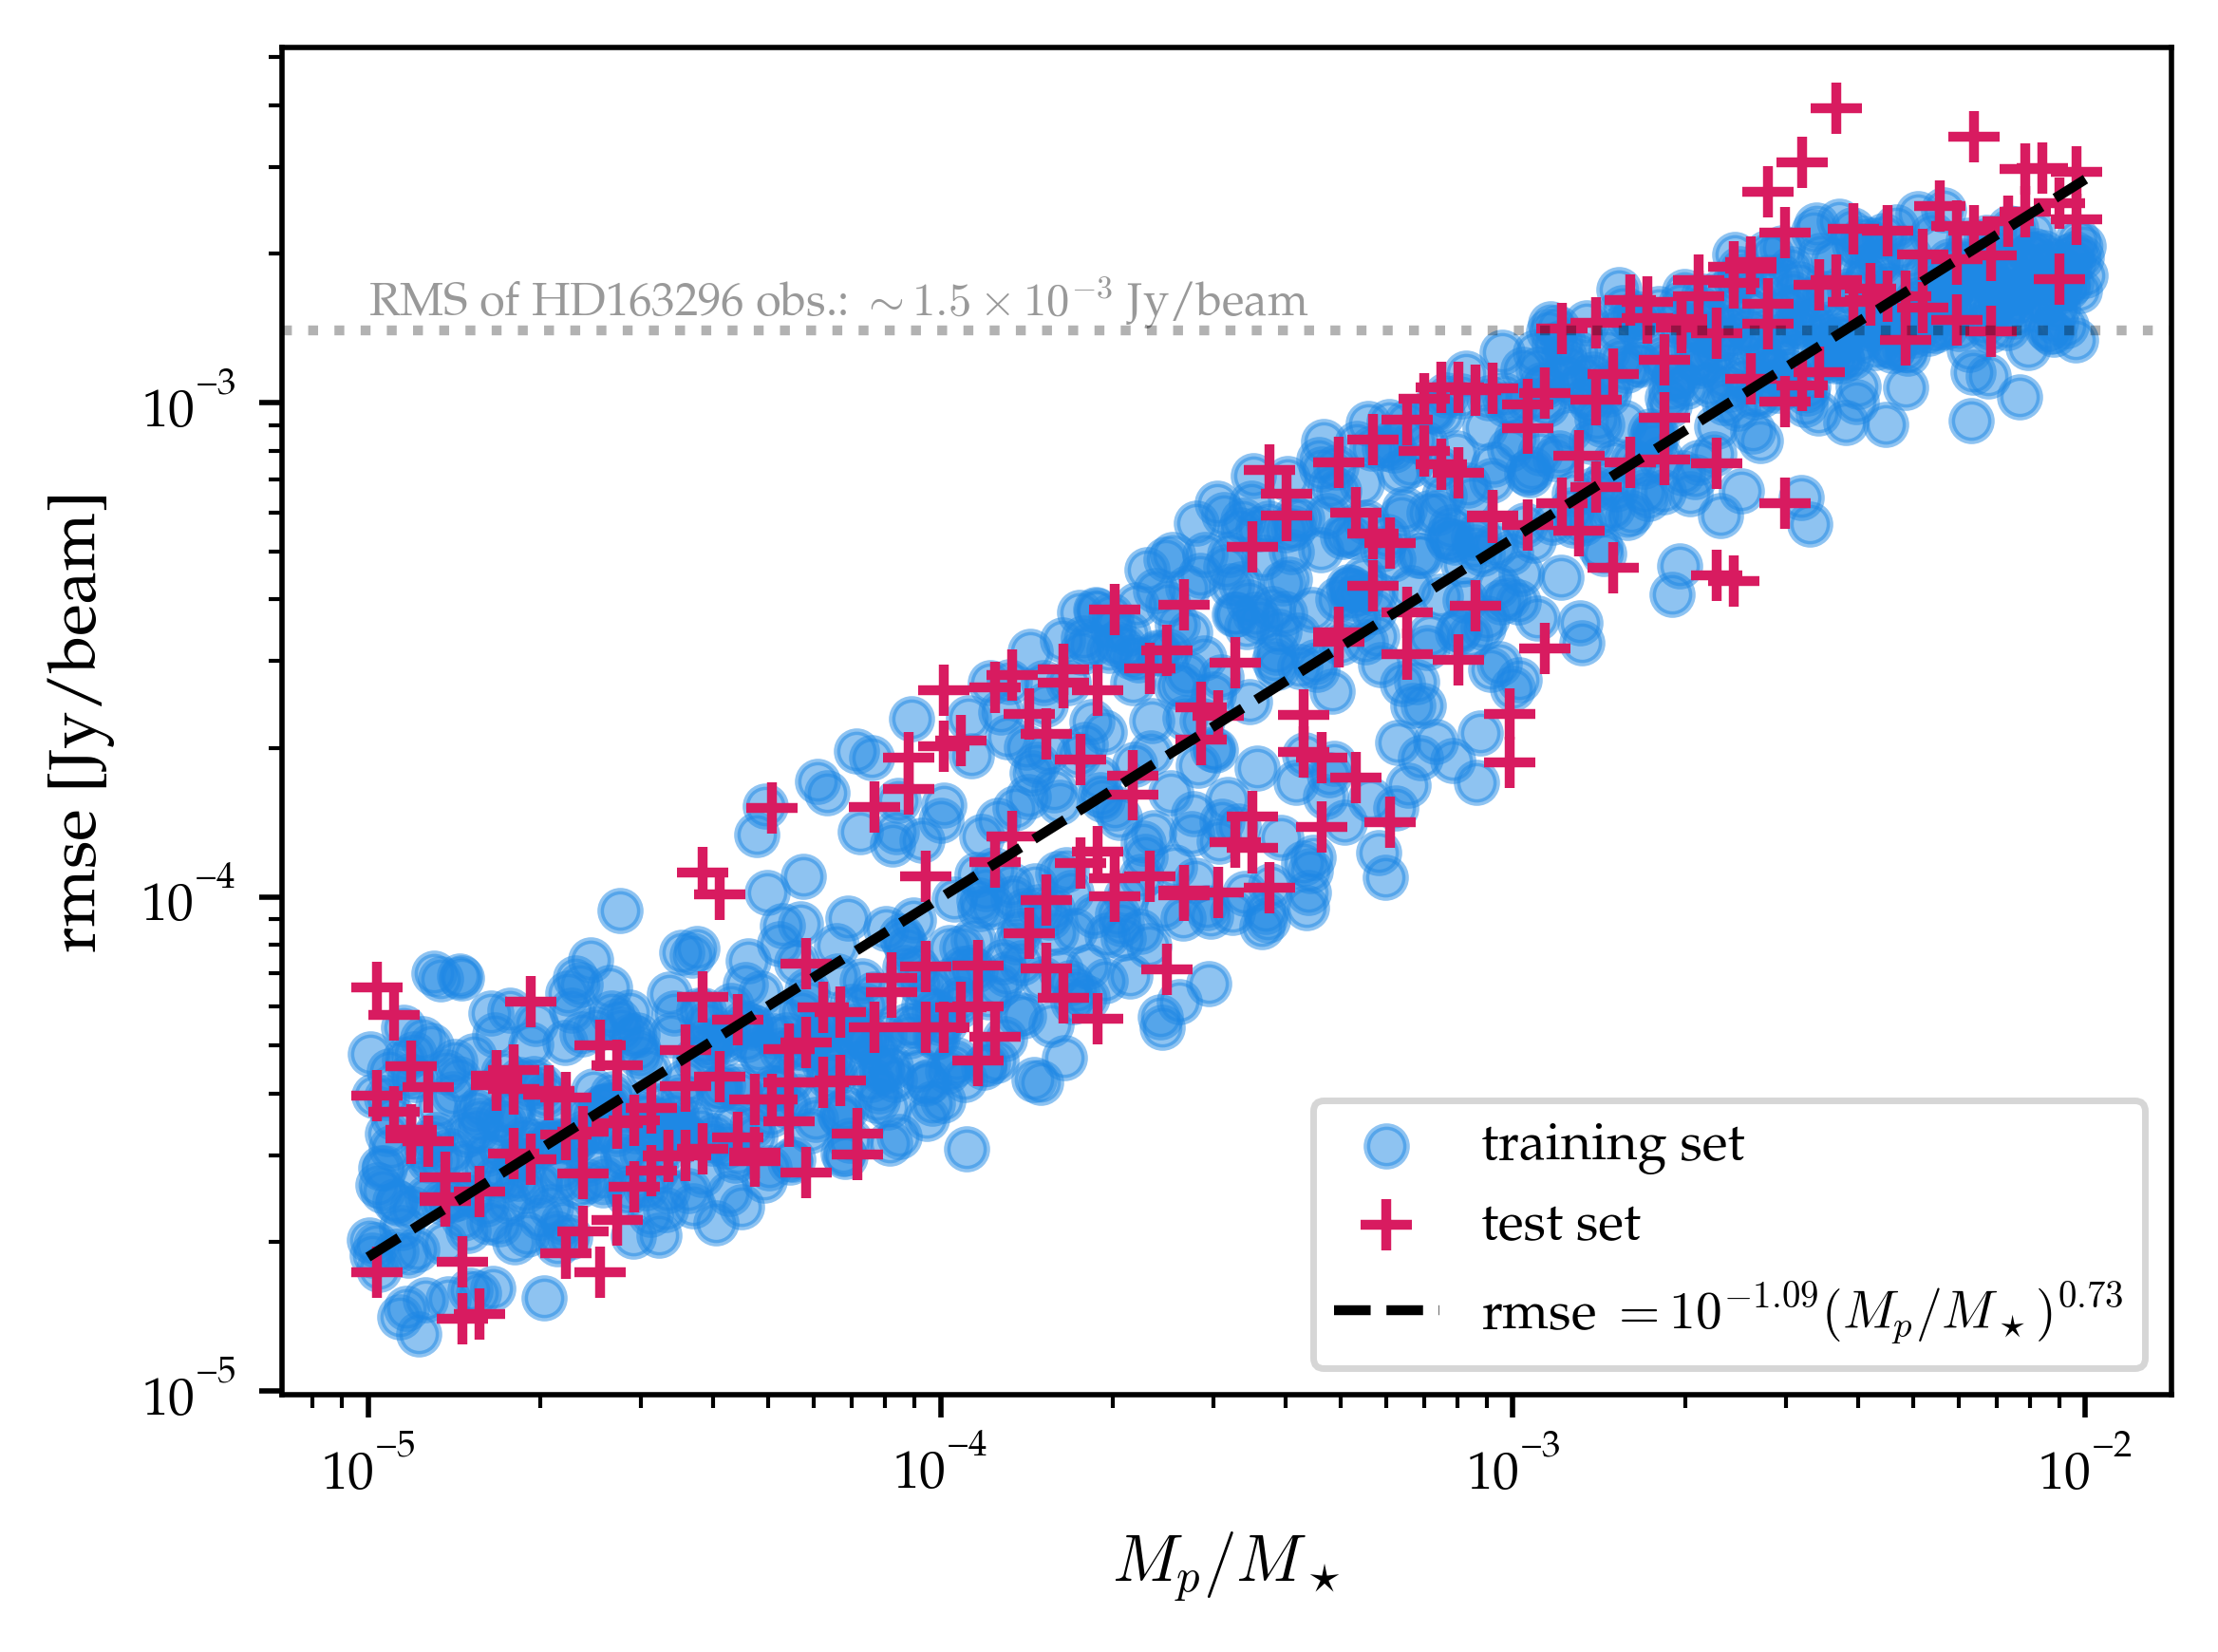

In [53]:

x = params['PlanetMass']
y = emulator_error

logx = np.log10(x)
logy = np.log10(y)
m1, b1 = np.polyfit(logx, logy, 1)
print(f"Fit:  y = 10^{b1:.3f} x^{m1:.3f}")

xfit = np.logspace(-5, -2, 100)
yfit = 10**(b1) * xfit**m1

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.scatter(x, y, alpha=0.5, color='#1E88E5', label='training set')
ax.scatter(params_test['PlanetMass'], emulator_error_test, color='#D81B60', marker='+', s=60, label='test set')

ll = 'rmse $= 10^{' + f'{b1:.2f}' + '}(M_p/M_\star)^{' + f'{m1:.2f}' + '}$'
ax.plot(xfit, yfit, label=ll, color='black', linestyle='--')
ax.axhline(1.4e-3, color='black', alpha=0.3, linestyle='dotted')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_p/M_\star$')
ax.set_ylabel('rmse [Jy/beam]')
ax.text(1e-5, 1.5e-3, r'RMS of HD163296 obs.: $\sim1.5\times10^{-3}$ Jy/beam',
        color='black', alpha=0.4, fontsize=7)  # small annotation, explicitly sized
ax.legend()

fig.tight_layout()
fig.savefig('MAIN_plots/emu_error_cmaps_training.pdf', dpi=500, bbox_inches='tight')

In [8]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import evaluation_lib as plot_gen
from tqdm import tqdm

testset_params = '../data/data/data/gas_tri_256/testpara.csv'
testparams = pd.read_csv(testset_params, index_col=0)

#load the data and parameters of the test set
testset_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like3corr.npy')
testset = testset_cmaps[:, 42:64] #only the central channels are present in the testset map
emulations = h5py.File("cmaps_emulations_small.h5", "r", swmr=True)

In [9]:
testparams

,InvStokes1,Alpha,AspectRatio,FlaringIndex,PlanetMass,SigmaSlope,nx,rout,ny
0,154.881662,0.001479,0.04435,0.09975,0.000327,0.6995,708.0,3,228.0
1,32.359366,0.000234,0.03525,0.25025,0.002786,1.0005,891.0,3,287.0
2,37.153523,0.002818,0.08635,0.04375,0.005188,0.5875,600.0,5,242.0
3,107.151931,0.001175,0.06045,0.01575,0.000031,0.5315,600.0,3,193.0
4,588.843655,0.006166,0.08565,0.30275,0.000610,1.1055,600.0,3,193.0
...,...,...,...,...,...,...,...,...,...
290,467.735141,0.000933,0.08915,0.23975,0.000010,0.9795,600.0,3,193.0
291,223.872114,0.003890,0.09895,0.34125,0.000027,1.1825,600.0,3,193.0
294,22.387211,0.001778,0.07235,0.30275,0.000164,1.1055,600.0,3,193.0
297,134.896288,0.008128,0.04155,0.09625,0.000124,0.6925,756.0,3,243.0


## Standard

In [ ]:
plot_gen.generate(emulations=emulations, testset=testset, testparams=testparams, savefolder='delme3', overwrite=True)

Saving folder exists, overwriting...
Computing things...


# Add noise and convolution with a beam to testset simulations

### generate convolved testset

In [19]:
#convolve 
import astropy.units as u
from astropy.convolution import Gaussian2DKernel

#Note that angles should be rechecked if changing the beam

Rmax = 380 * u.au
npix = 250
dpc = 101.5 * u.pc
beam_size_mas_amaj = 104 * u.mas
beam_size_mas_amin = 94 * u.mas
beam_size_pa = 90-80.2 #deg

dpix = np.arctan((Rmax.to('au') / (0.5*(npix-1))) / dpc.to('pc')).to(u.deg)

sigma_maj_pix = beam_size_mas_amaj/dpix / 2.35
sigma_min_pix = beam_size_mas_amin/dpix / 2.35

kernel = Gaussian2DKernel( sigma_maj_pix, sigma_min_pix, beam_size_pa)
rms = 6.2e-3 #Jy/px -> same as Pinte+2018 observation

### Generate data (run only if files are not present)

In [ ]:
noise = np.random.normal(0, rms, testset.shape)
noisy_testset = noise+testset
noisy_convolved_testset = convolve(noisy_testset, kernel, axes=(-1,-2))

In [9]:
emulations_convolved = {}
for par in tqdm(['PlanetMass', 'AspectRatio', 'Alpha']):
    emulations_convolved[par] = convolve(emulations[par], kernel, axes=(-1,-2))

100%|████████████████████████████████████████████| 3/3 [41:43<00:00, 834.48s/it]


In [23]:
np.save('convolved_emulations.npy', emulations_convolved)
np.save('noisy_convolved_testset.npy', noisy_convolved_testset)

### Load

In [18]:
emulations_convolved = np.load('convolved_emulations.npy', allow_pickle=True).item()
noisy_convolved_testset = np.load('noisy_convolved_testset.npy', allow_pickle=True)

### Save single element for mcmc test

In [23]:
np.save('target_id2.npy', noisy_convolved_testset[2])

(np.float64(-0.5), np.float64(249.5), np.float64(249.5), np.float64(-0.5))

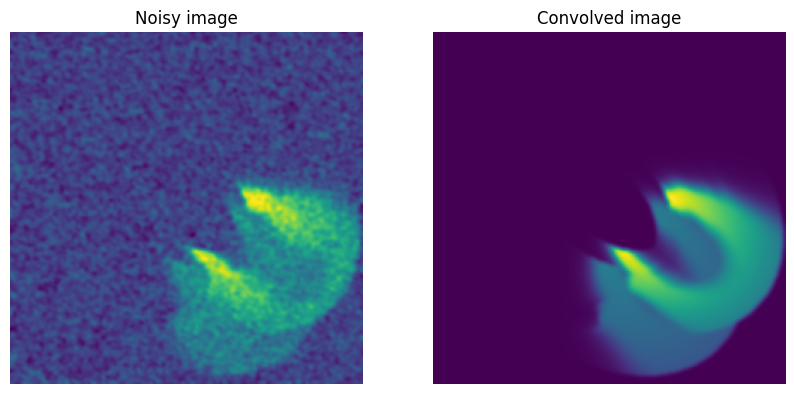

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[1].imshow(emulations_convolved['PlanetMass'][17, 15, 15])
axs[0].imshow(noisy_convolved_testset[2,15])

axs[0].set_title('Noisy image')
axs[1].set_title('Convolved image')

axs[0].axis('off')
axs[1].axis('off')

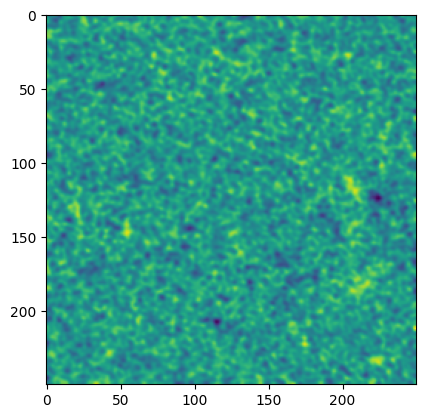

In [6]:
plt.imshow(emulations_convolved['PlanetMass'][17, 15, 15]-noisy_convolved_testset[17,15])

# Running the fitting test with varying $\alpha$

## Common code: compute the mse

In [20]:
mse_varp_testset = {}
for para in emulations_convolved.keys():
    mse_varp_testset[para] = np.empty(emulations_convolved[para].shape[0:2])
    for i in range(emulations_convolved[para].shape[0]):
        mse_varp_testset[para][i] = ((emulations_convolved[para][i]-np.expand_dims(noisy_convolved_testset[i], axis=0))**2).sum(axis=(-1,-2,-3))


KeyboardInterrupt: 

## Standard Likelihood

In [ ]:
# compute noise 
noise = []
for datacube in noisy_convolved_testset:
    noise.append(np.std(np.append(datacube[:5,0:50,-50:], datacube[-5:,:50,-50:], axis=0)))

rms = np.mean(noise)
print('rms: ', rms)
likelihood_varp_testset = mse_varp_testset.copy()
for para in likelihood_varp_testset.keys():
    likelihood_varp_testset[para] = 0.5*likelihood_varp_testset[para]/rms**2

rms:  0.0012802273524686227


In [ ]:
rms

np.float64(0.0012802273524686227)

In [ ]:
bestest, errs, sigmas = plot_gen.get_best_likeeqpost(None, None, 1, mse=likelihood_varp_testset)

100%|██████████| 3/3 [00:00<00:00, 103.90it/s]


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/scratch/ipykernel_2268313/3262317106.py:3: SyntaxWarning: invalid escape sequence '\s'
  labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}


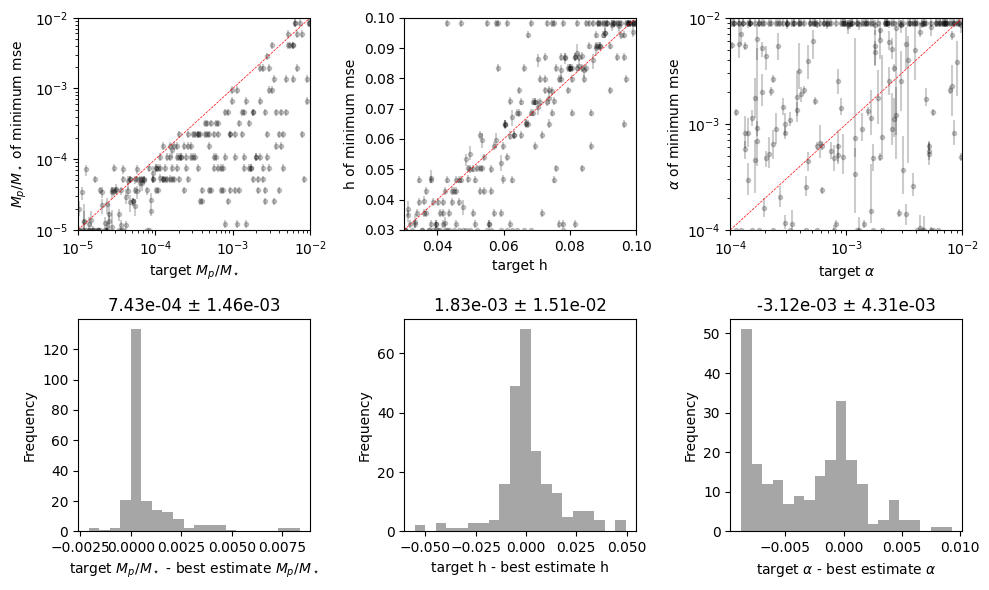

In [ ]:
fig, axsb = plt.subplots(2, 3, figsize=(10,6))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb[0]
axs2 = axsb[1]
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])
    axs2[i].hist(err, bins=20, color='gray', alpha=0.7)
    axs2[i].set_xlabel(f'target {labels[para]} - best estimate {labels[para]}')
    axs2[i].set_ylabel('Frequency')
    axs2[i].set_title(f'{err.mean():.2e} ± {err.std():.2e}')

plt.tight_layout()
plt.savefig('MAIN_plots/main_standard_gauss.png', dpi=500, bbox_inches='tight')

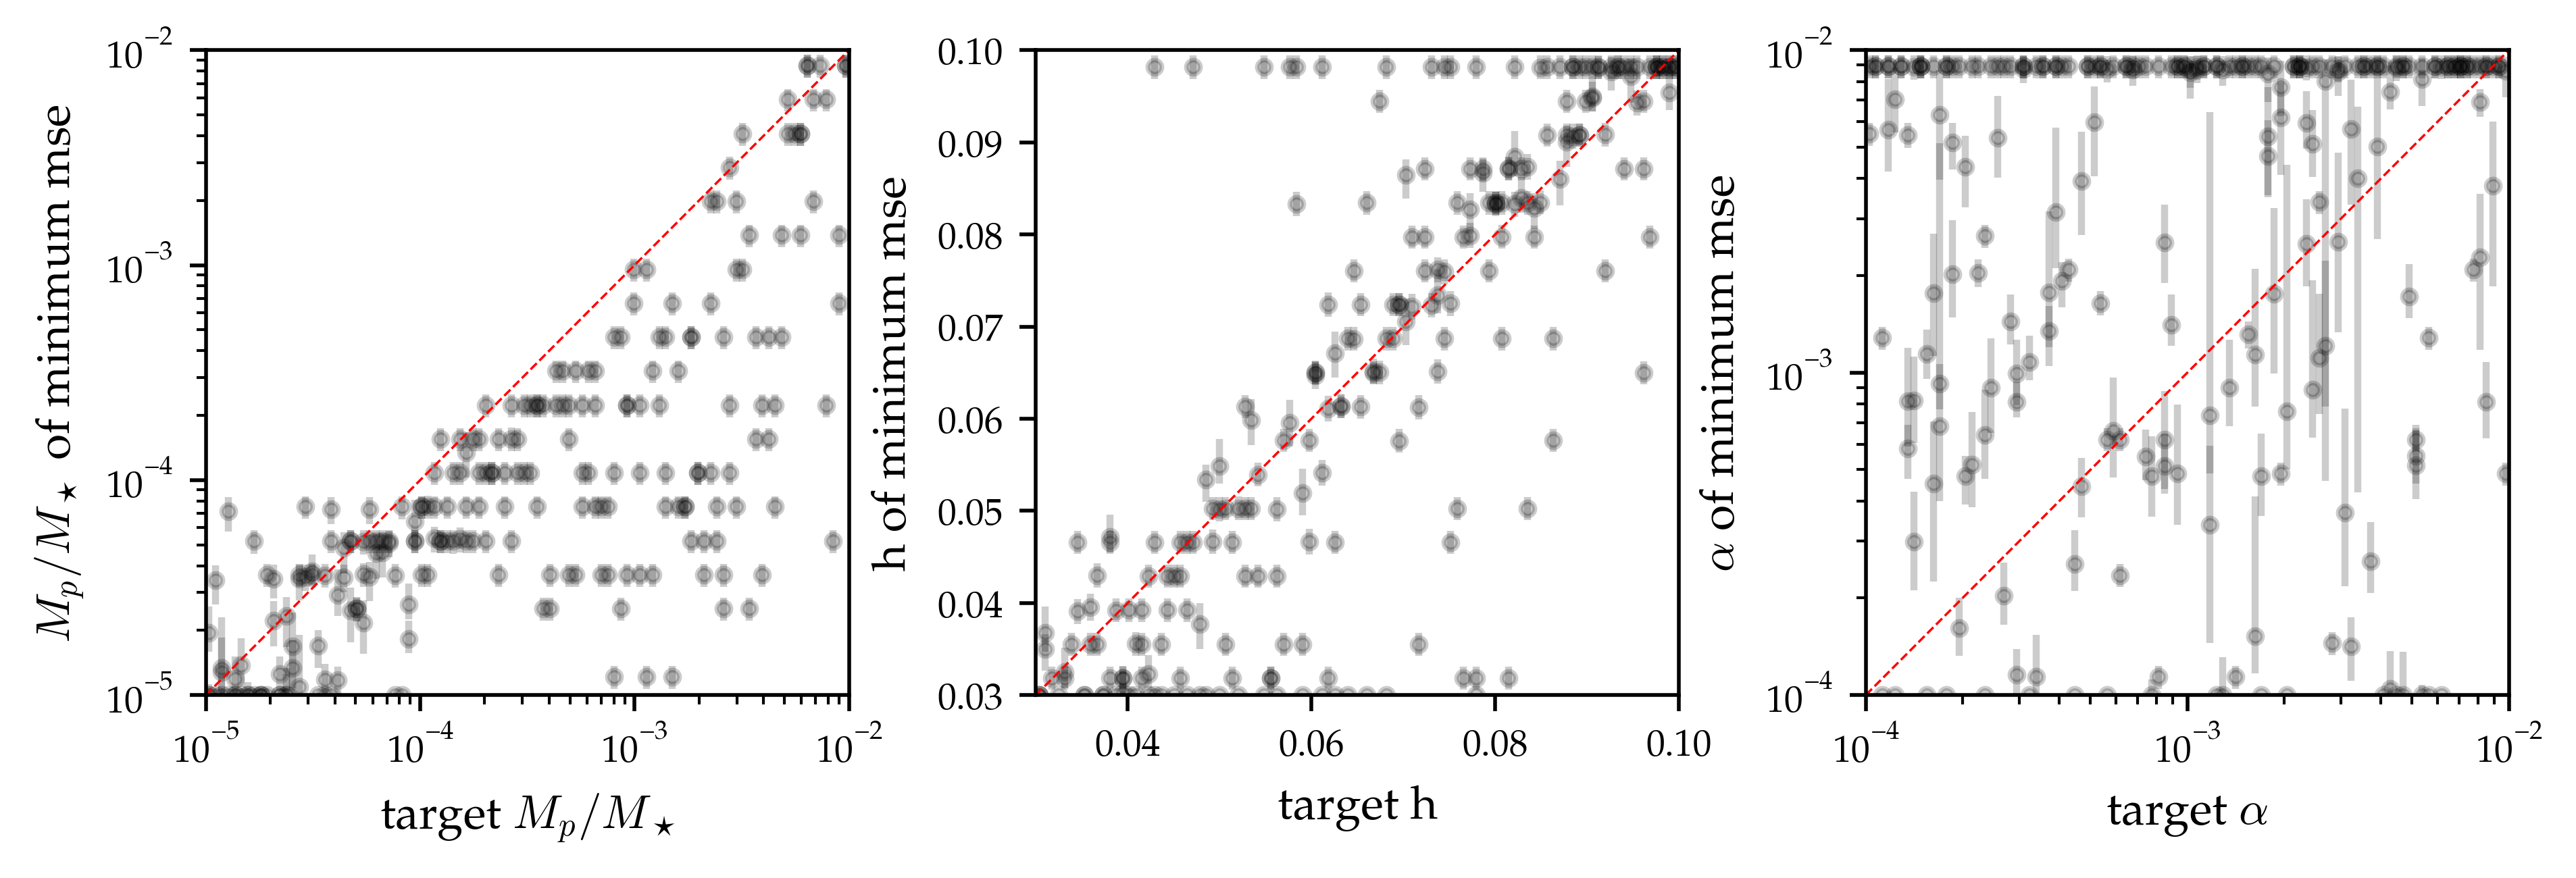

In [ ]:
fig, axsb = plt.subplots(1, 3, figsize=(10,6))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb
axs2 = axsb[1]
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])
    #axs2[i].hist(err, bins=20, color='gray', alpha=0.7)
    #axs2[i].set_xlabel(f'target {labels[para]} - best estimate {labels[para]}')
    #axs2[i].set_ylabel('Frequency')
    #axs2[i].set_title(f'{err.mean():.2e} ± {err.std():.2e}')

plt.tight_layout()
plt.gcf().set_size_inches(7.5,2.2)
plt.savefig('MAIN_plots/main_standard_gauss_1r.pdf', dpi=500, bbox_inches='tight')

## Conditioning test with sigma dependent on planet mass

In [ ]:
# SAME FOR ALL PIXELS
# Compute best estimates and errors from the mse curves
#only vr
from evaluation_lib import get_best_likeeqpost

sigmas_mp = 10**(2*(np.linspace(-5,-2,20)*0.67-1.54)).reshape(1,-1)+rms**2

grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}

sigmas_other = np.array(10**(2*(np.log10(testparams['PlanetMass'])*0.67-1.54))).reshape(-1,1) + rms**2

#sum_factor = np.prod(noisy_convolved_testset.shape[1:])
sum_factor = np.count_nonzero(testset, axis=(1,2,3)).mean()

mses = {key: mse_varp_testset[key][:,:]/(2*sigmas) + 0.5*sum_factor*np.log(2*np.pi*sigmas) for key, sigmas in zip(mse_varp_testset.keys(), [sigmas_mp, sigmas_other, sigmas_other])}
bestest, errs, sigmas = get_best_likeeqpost(None, None, sigma=1, mse=mses, grids=grids)


MODEL ERROR ONLY WHERE EMULATION IS NOT ZERO

In [ ]:
# THIS IS EXPENSIVE THUS RUN ONLY IF NEEDED
from tqdm import tqdm
mses = {}
for key in tqdm(mse_varp_testset.keys()):
    if key=='PlanetMass':
        sigmas = rms**2 + (emulations_convolved[key]!=0).astype(int)*(10**(2*(np.linspace(-5,-2,20)*0.67-1.54))).reshape(1,-1,1,1,1)
    else:
        sigmas = rms**2 + (emulations_convolved[key]!=0).astype(int)*np.array(10**(2*(np.log10(testparams['PlanetMass'])*0.67-1.54))).reshape(-1,1,1,1,1)
    #sum_factor = (emulations_convolved[key]!=0).sum(axis=(2,3,4))
    mses[key] = 0.5*((emulations_convolved[key]-np.expand_dims(noisy_convolved_testset, axis=1))**2/sigmas).sum(axis=(2,3,4)) + (0.5*np.log(2*np.pi*sigmas)).sum(axis=(2,3,4))
np.save('backup_mse_varsigmam.npy', mses)

100%|██████████| 3/3 [08:47<00:00, 175.73s/it]


In [ ]:
from evaluation_lib import get_best_likeeqpost
mses = np.load('backup_mse_varsigmam.npy')
grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}
bestest, errs, sigmas = get_best_likeeqpost(None, None, sigma=1, mse=mses, grids=grids)


100%|██████████| 3/3 [00:00<00:00, 874.24it/s]


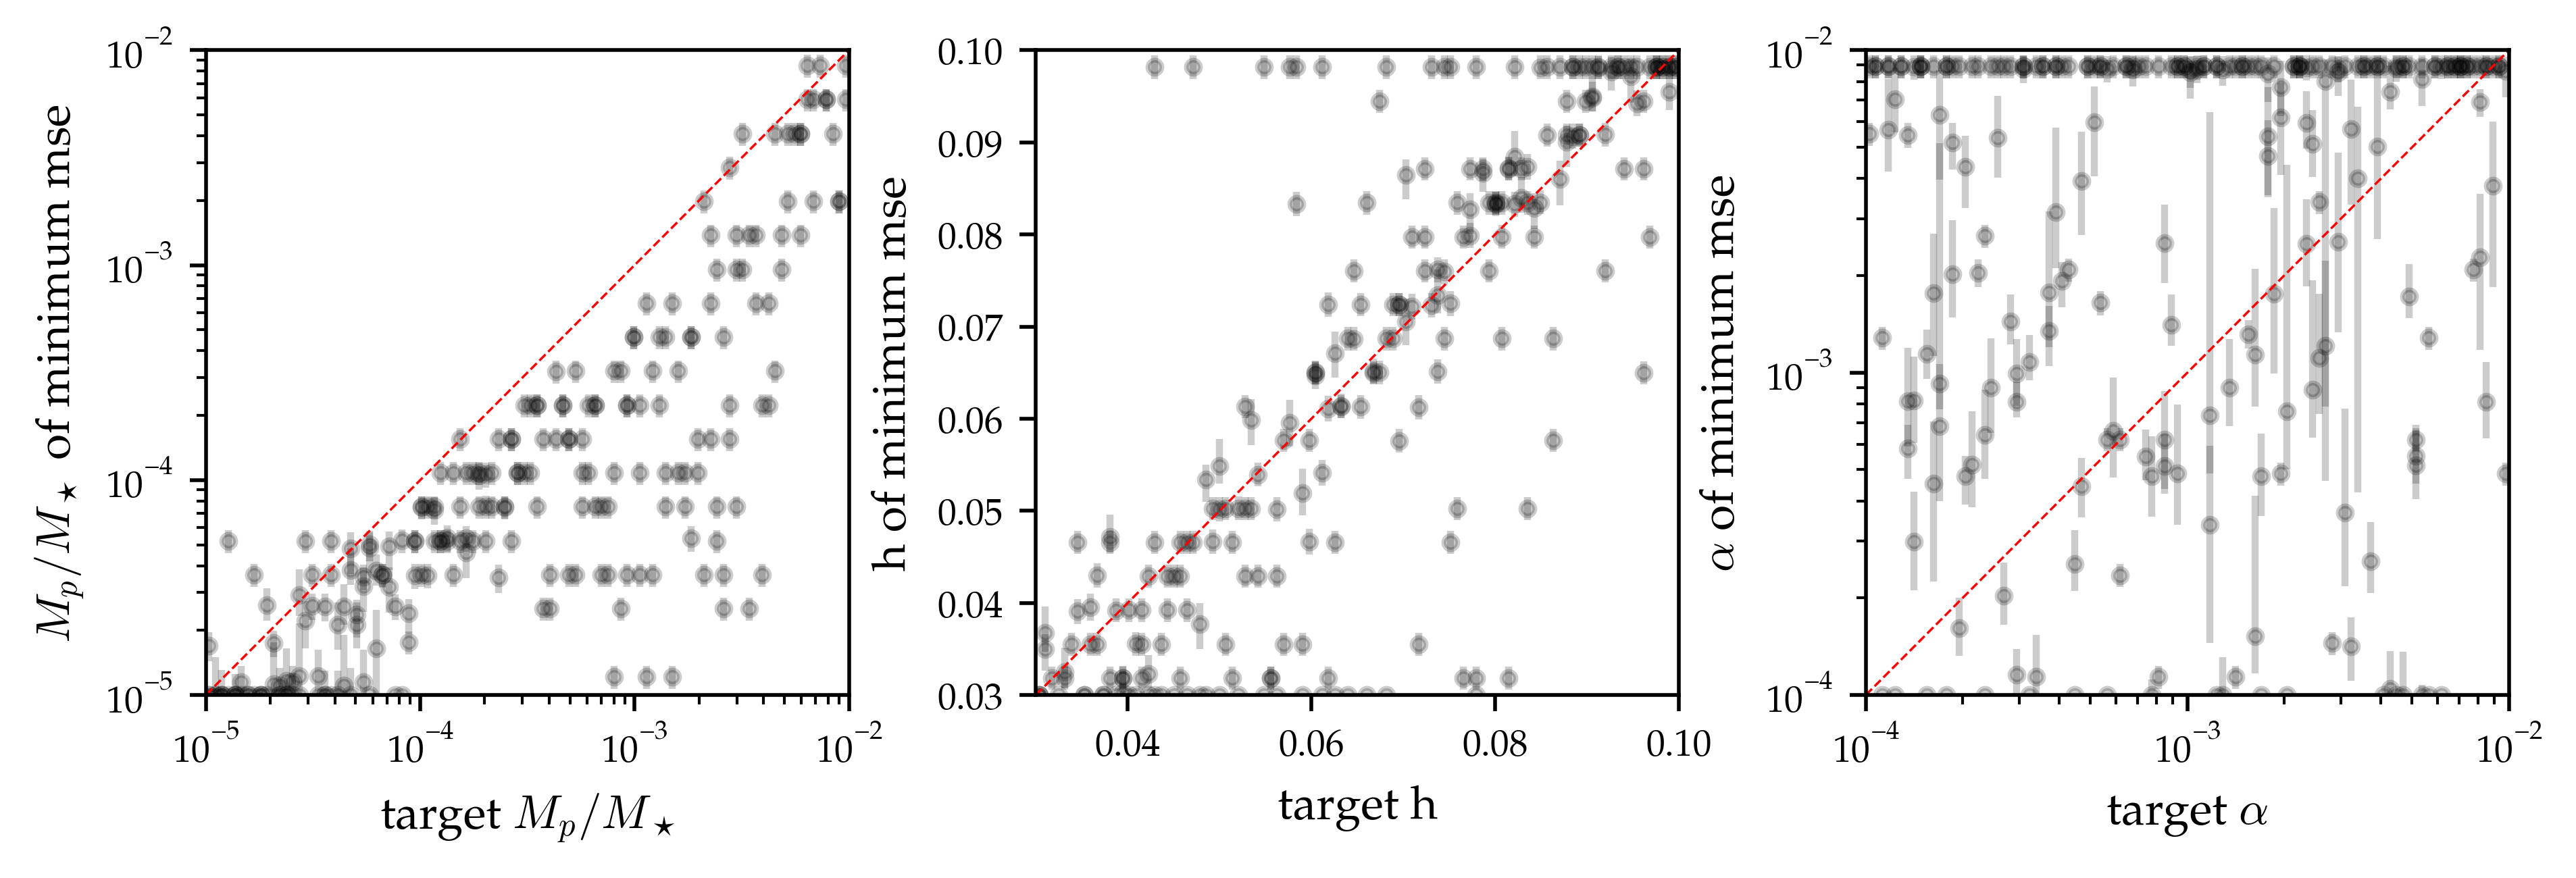

In [ ]:
fig, axsb = plt.subplots(1, 3, figsize=(10,6))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb#[0]
axs2 = axsb[1]
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])
    #axs2[i].hist(err, bins=20, color='gray', alpha=0.7)
    #axs2[i].set_xlabel(f'target {labels[para]} - best estimate {labels[para]}')
    #axs2[i].set_ylabel('Frequency')
    #axs2[i].set_title(f'{err.mean():.2e} ± {err.std():.2e}')

plt.tight_layout()
plt.gcf().set_size_inches(7.5,2.2)
plt.savefig('MAIN_plots/main_gauss_modelunc.png', dpi=500, bbox_inches='tight')

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/scratch/ipykernel_2268313/461476643.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Error on $M_p/M_\star$ [dex]')


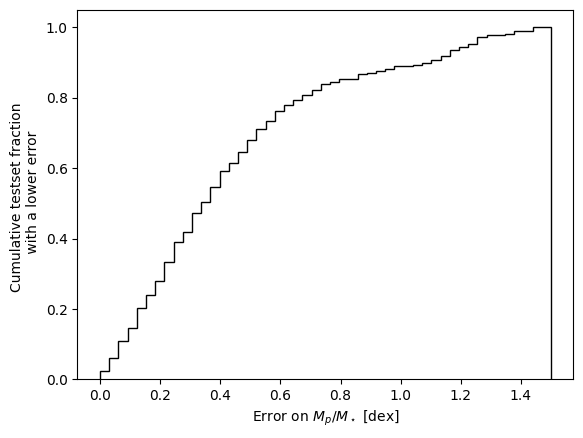

In [ ]:
para = 'PlanetMass'
relerr = np.abs(np.log10(testparams[para])-np.log10(bestest[para]))
plt.hist(relerr, bins=np.linspace(0,1.5,50), histtype='step', cumulative=True, color='black', density=True)
plt.xlabel('Error on $M_p/M_\star$ [dex]')
plt.ylabel('Cumulative testset fraction \n with a lower error')
#plt.gca().set_aspect('equal')
#plt.xscale('log')
plt.savefig(f'plots/tmass_cumdist.png', dpi=500, bbox_inches='tight')


## Taking spatial correlation into account

In [ ]:
#convolve 
import astropy.units as u
from astropy.convolution import Gaussian2DKernel

#Note that angles should be rechecked if changing the beam

Rmax = 380 * u.au
npix = 250
dpc = 101.5 * u.pc
beam_size_mas_amaj = 104 * u.mas
beam_size_mas_amin = 94 * u.mas
beam_size_pa = 90-80.2 #deg

dpix = np.arctan((Rmax.to('au') / (0.5*(npix-1))) / dpc.to('pc')).to(u.deg)

sigma_maj_pix = beam_size_mas_amaj/dpix / 2.35
sigma_min_pix = beam_size_mas_amin/dpix / 2.35

kernel = Gaussian2DKernel( sigma_maj_pix, sigma_min_pix, beam_size_pa,x_size=250, y_size=250)
rms = 6.2e-3 #Jy/px -> same as Pinte+2018 observation

In [ ]:
import numpy as np
from scipy.fft import fft2, ifft2
noise = rms
Ny, Nx = emulations_convolved['PlanetMass'][0][0][0].shape
pad_shape = (2 * Ny, 2 * Nx) 

# 1. Align phase center [0, 0]
cy, cx = kernel.shape[0] // 2, kernel.shape[1] // 2
kernel_shifted = np.roll(kernel, shift=(-cy, -cx), axis=(0, 1))

# 2. Forward FFT of the beam
fkernel = fft2(kernel_shifted, s=pad_shape, workers=-1)

# 3. Compute |F(B)|^2 
# To fix the normalization perfectly regardless of physical pixel size units,
# we force the discrete inverse-transform of the power spectrum to have a 
# peak value (zero-lag variance) exactly equal to noise**2.
power_spectrum = np.abs(fkernel)**2

# Find what the discrete peak value would be in real-space
# (The peak of a circular autocorrelation always lands at index [0,0])
discrete_b_cov = np.real(ifft2(power_spectrum, workers=-1))
discrete_peak = discrete_b_cov[0, 0]

# Apply the exact normalization factor
FBcov = (noise**2) * (power_spectrum / discrete_peak)

def get_chi2_fft_normalized(r, kernel, noise):
    """
    Computes the exact, fully normalized chi^2 spatial covariance penalty.
    """
    # 4. Transform the residuals
    Fr = fft2(r, s=pad_shape, workers=-1)
    
    # 5. Element-wise division 
    Finv_Sigma_r = Fr / (FBcov + 1e-16)
    
    # 6. Bring back to pixel space and crop
    inv_Sigma_r_padded = np.real(ifft2(Finv_Sigma_r, workers=-1))
    inv_Sigma_r = inv_Sigma_r_padded[:Ny, :Nx]
    
    # 7. Compute the scalar chi2
    chi2 = np.sum(r * inv_Sigma_r)
    
    return chi2


def get_chi2_from_convolved_rms(r, kernel, convolved_rms):
    """
    Computes reduced chi-squared using ONLY the post-convolved image RMS.
    Perfect for real observations where the original white noise level is unknown.
    """
    N = np.prod(r.shape)
    
    # 1. Calculate the spatial sum of squares of the kernel
    kernel_sum_sq = np.sum(kernel.array**2)
    
    # 2. Reverse-engineer the original underlying white noise variance (rms_white^2)
    # sigma^2_white = sigma^2_convolved / sum(K^2)
    var_white = (convolved_rms**2) / kernel_sum_sq
    
    # 3. Fourier transform the residual using standard unnormalized FFT
    fr = np.fft.fft2(r)
    fr_power = np.abs(fr)**2
    
    # 4. Fourier transform the shifted kernel
    fkern = np.fft.fft2(np.fft.fftshift(kernel.array))
    
    # 5. Construct the perfect Power Spectral Density profile.
    # In standard FFT space, the white noise power spectrum is flat at (N * var_white).
    # The filtered power spectrum is (N * var_white) * |F(K)|^2.
    FBcov = N * var_white * np.abs(fkern)**2
    
    # 6. Filter out instrument dead zones (high frequency cutoff)
    mask = FBcov > (1e-5 * np.max(FBcov))
    
    # 7. Compute the reduced Chi2
    chi2_total = np.sum(fr_power[mask] / FBcov[mask])
    #degrees_of_freedom = np.sum(mask)
    
    return chi2_total

In [ ]:
from tqdm import tqdm
all = {k: [] for k in emulations_convolved.keys()}

for key in emulations_convolved.keys():
    for i, sliceA in tqdm(enumerate(emulations_convolved[key])):
        all2 = []
        for sliceB in sliceA:
            chi2 = 0.0
            for j, c in enumerate(sliceB):
                chi2 += get_chi2_from_convolved_rms(c-noisy_convolved_testset[i, j], kernel, rms)
            all2.append(chi2)
        all[key].append(all2)

233it [03:13,  1.20it/s]
233it [02:55,  1.33it/s]
233it [02:55,  1.32it/s]


In [ ]:
emulations_convolved.keys()

dict_keys(['PlanetMass', 'AspectRatio', 'Alpha'])

In [ ]:
v = all['PlanetMass']
mse = {'PlanetMass': v[:233], 'AspectRatio': v[233:466], 'Alpha': v[466:]}
from evaluation_lib import get_best_likeeqpost
vals = np.array(all)
grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}
#mse = {'PlanetMass': vals, 'Alpha': vals, 'AspectRatio': vals}
bestest, errs, sigmas = get_best_likeeqpost(None, None, sigma=1, mse=mse, grids=grids)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 517.45it/s]


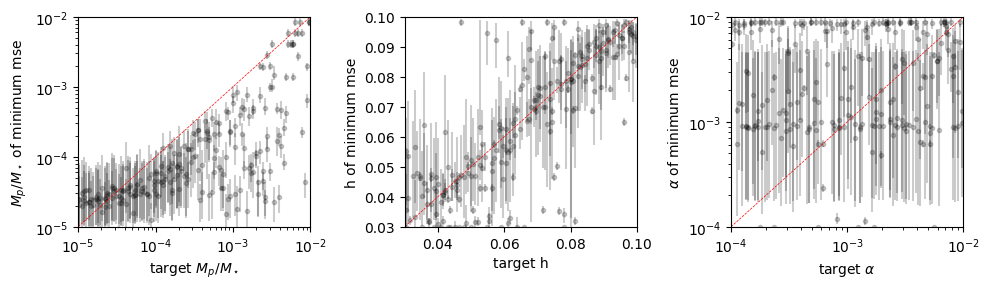

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10,3))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

plt.tight_layout()
plt.savefig('plots/varp_all_mp_cmaps_varyingsigmaemu_tplanetmass_sc.pdf', dpi=500, bbox_inches='tight')

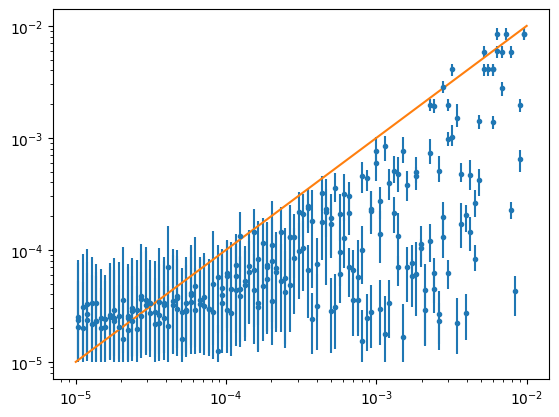

In [ ]:
plt.errorbar(testparams['PlanetMass'], bestest['PlanetMass'], yerr=errs['PlanetMass'], fmt='.')
plt.plot([1e-5, 1e-2], [1e-5, 1e-2])
plt.xscale('log')
plt.yscale('log')

# Running the fitting test with $\alpha=10^{-2}$ 

In [ ]:
#convolve and save the emulations
emulationsa2 = h5py.File("cmaps_emulations_small_ALLalpha1e-2.h5", "r", swmr=True)
emulationsa2_convolved = {}
for par in tqdm(['PlanetMass', 'AspectRatio']):
    emulationsa2_convolved[par] = convolve(emulationsa2[par], kernel, axes=(-1,-2))
np.save('emulationsa2_convolved.npy', emulationsa2_convolved)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [30:28<00:00, 914.30s/it]


In [14]:
#load the convolved data
emulationsa2_convolved = np.load('emulationsa2_convolved.npy', allow_pickle=True).item()

In [21]:
mse_varp_testset = {}
for para in emulationsa2_convolved.keys():
    mse_varp_testset[para] = np.empty(emulationsa2_convolved[para].shape[0:2])
    for i in range(emulationsa2_convolved[para].shape[0]):
        mse_varp_testset[para][i] = ((emulationsa2_convolved[para][i]-np.expand_dims(noisy_convolved_testset[i], axis=0))**2).sum(axis=(-1,-2,-3))


## No model error

In [ ]:
# compute noise 
noise = []
for datacube in noisy_convolved_testset:
    noise.append(np.std(np.append(datacube[:5,0:50,-50:], datacube[-5:,:50,-50:], axis=0)))

rms = np.mean(noise)

likelihood_varp_testset = mse_varp_testset.copy()
for para in likelihood_varp_testset.keys():
    likelihood_varp_testset[para] = 0.5*likelihood_varp_testset[para]/rms**2

In [ ]:
bestest, errs, sigmas = plot_gen.get_best_likeeqpost(None, None, 1, mse=likelihood_varp_testset)

100%|██████████| 3/3 [00:00<00:00, 713.60it/s]


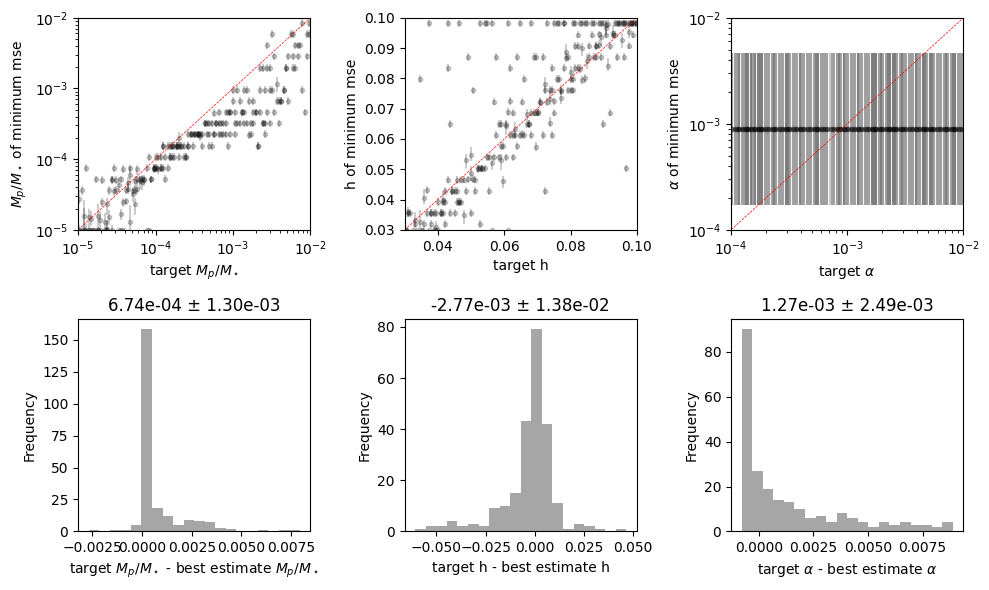

In [21]:
fig, axsb = plt.subplots(2, 3, figsize=(10,6))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb[0]
axs2 = axsb[1]
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])
    axs2[i].hist(err, bins=20, color='gray', alpha=0.7)
    axs2[i].set_xlabel(f'target {labels[para]} - best estimate {labels[para]}')
    axs2[i].set_ylabel('Frequency')
    axs2[i].set_title(f'{err.mean():.2e} ± {err.std():.2e}')

plt.tight_layout()
plt.savefig('MAIN_plots/main_standard_gauss_a2.png', dpi=500, bbox_inches='tight')

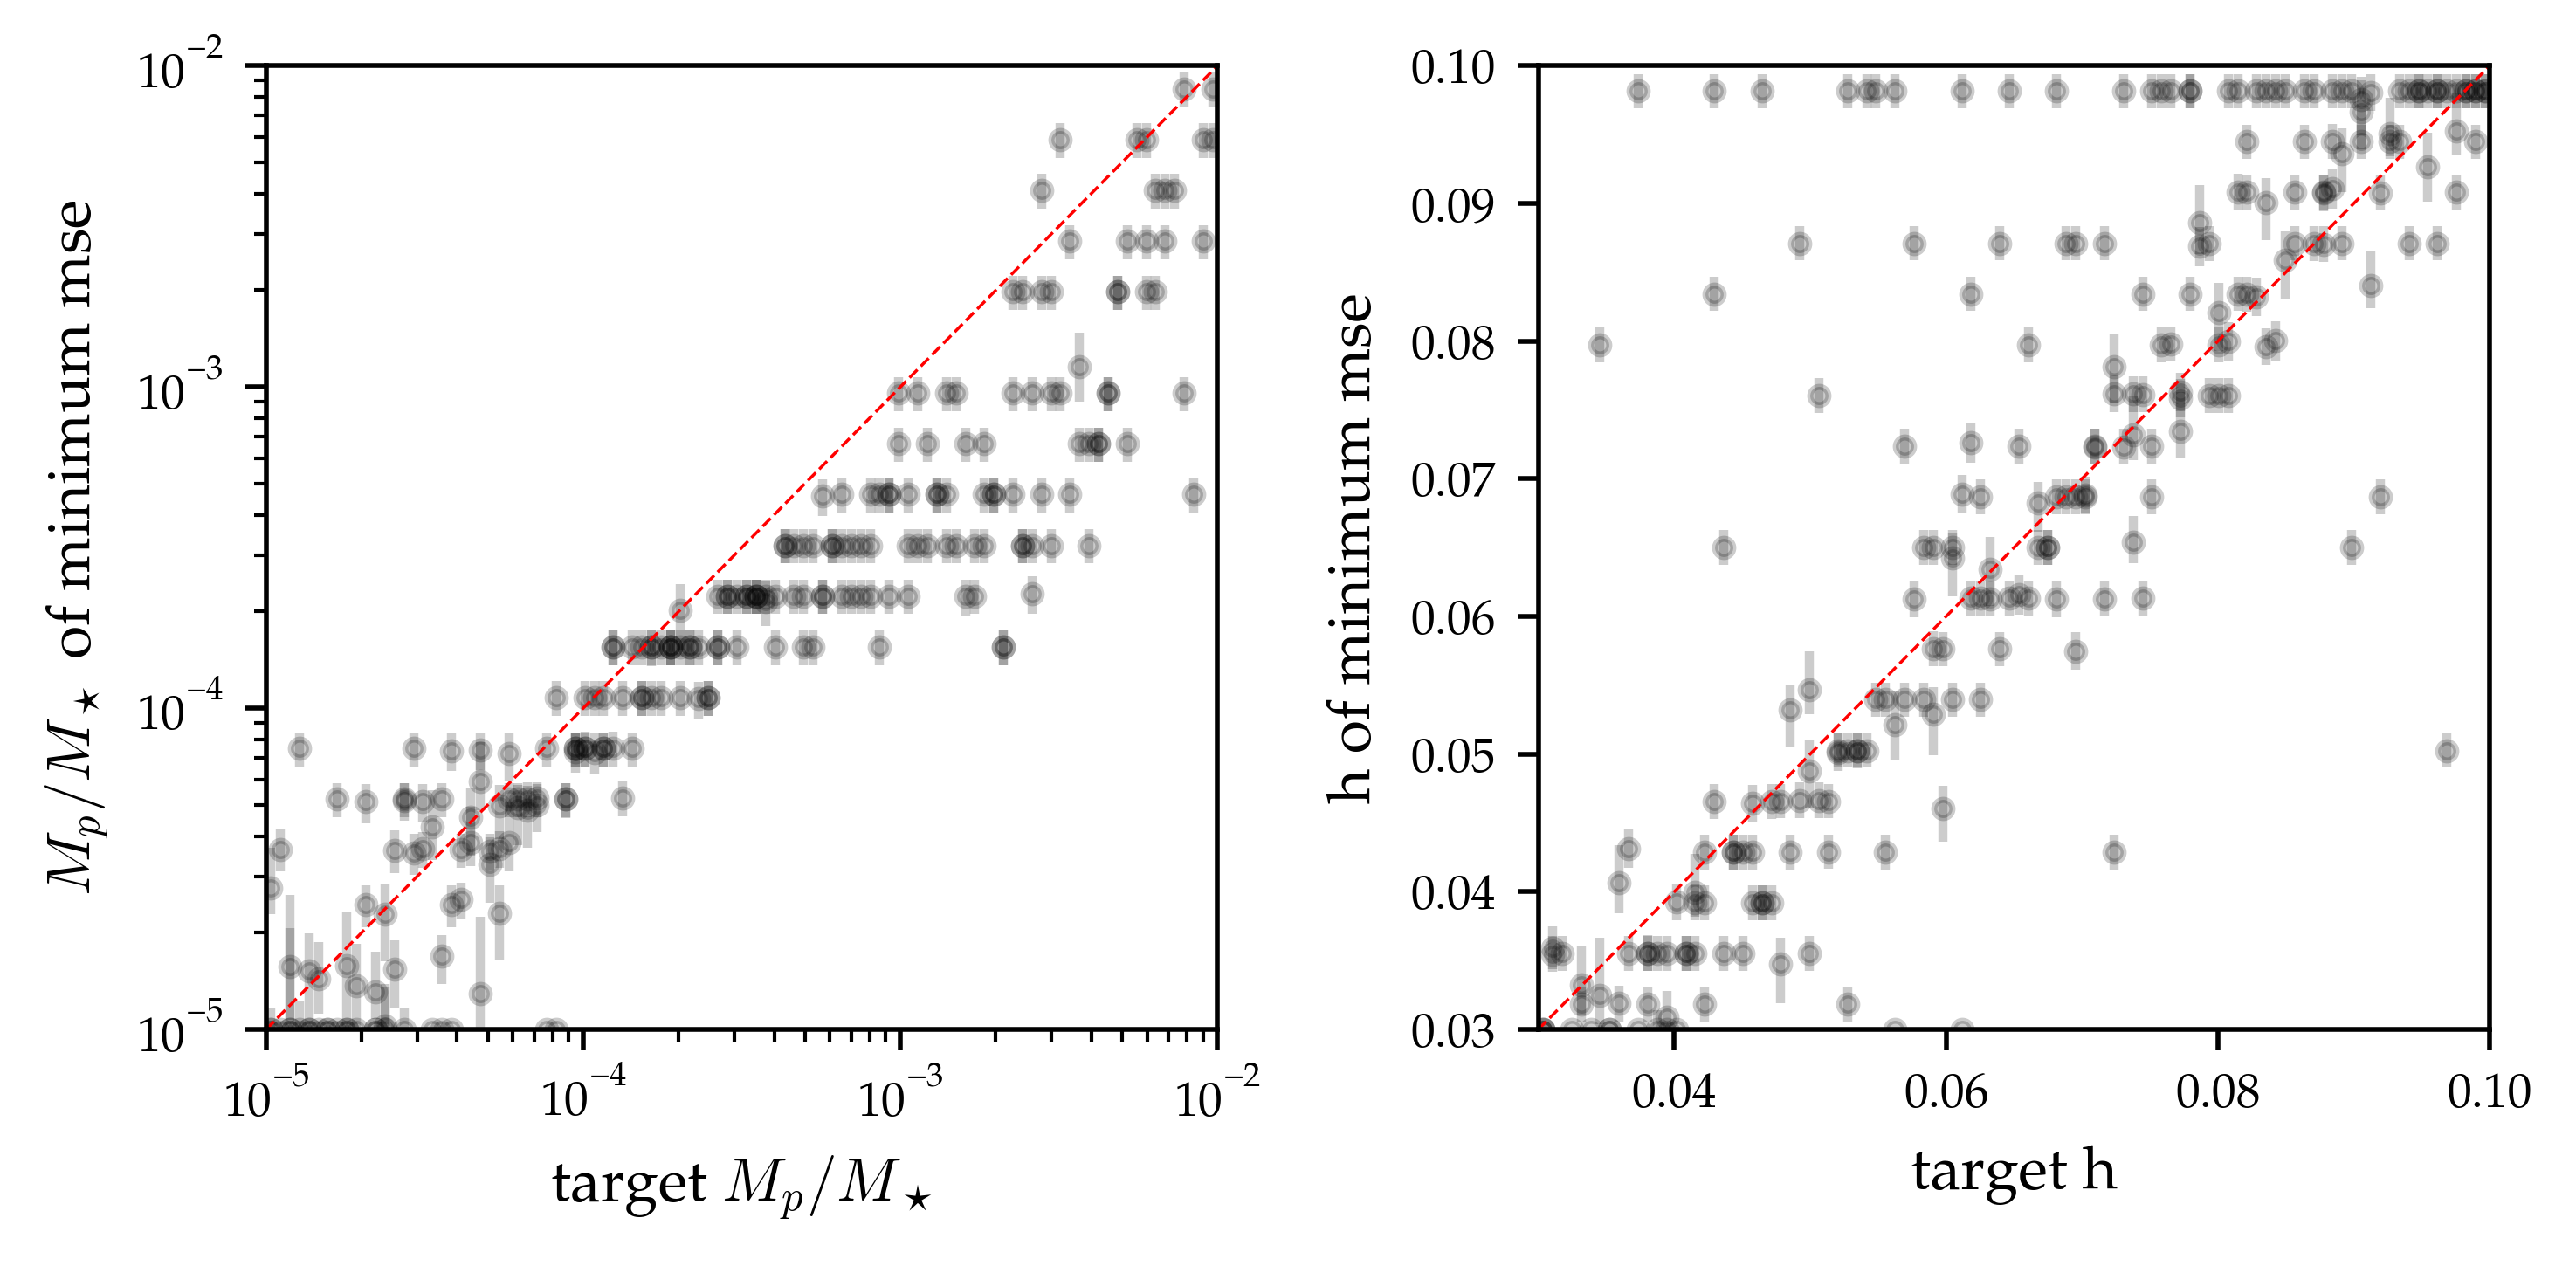

In [96]:
fig, axsb = plt.subplots(1, 2, figsize=(6,3))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb
for i, para in enumerate(['PlanetMass', 'AspectRatio']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])

plt.tight_layout()
plt.savefig('MAIN_plots/main_standard_gauss_a2_simple.png', dpi=500, bbox_inches='tight')

/scratch/ipykernel_1345966/1501317881.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


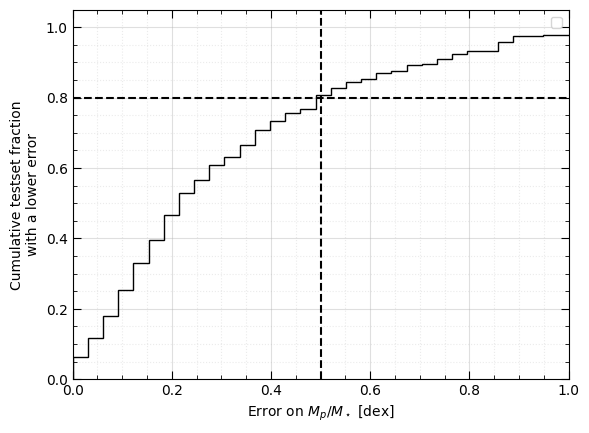

In [30]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

para = 'PlanetMass'
relerr = np.abs(np.log10(testparams[para]) - np.log10(bestest[para]))
# relerra2 = np.abs(np.log10(testparams[para]) - np.log10(bestesta2[para]))

fig, ax = plt.subplots()

ax.hist(
    relerr,
    bins=np.linspace(0, 1.5, 50),
    histtype='step',
    cumulative=True,
    color='black',
    density=True,
)

# ax.hist(
#     relerra2,
#     bins=np.linspace(0, 1.5, 50),
#     histtype='step',
#     cumulative=True,
#     color='blue',
#     density=True,
#     label=r'fixed viscosity $\alpha=10^{-2}$'
# )

ax.set_xlabel(r'Error on $M_p/M_\star$ [dex]')
ax.set_ylabel('Cumulative testset fraction\nwith a lower error')

ax.set_xlim(0, 1)
ax.axvline(0.5, color='k', linestyle='--')

# Minor ticks
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# Grid
ax.grid(which='major', linestyle='-', alpha=0.4)
ax.grid(which='minor', linestyle=':', alpha=0.25)

# Ticks on all sides, pointing inward
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6)
ax.tick_params(which='minor', length=3)
ax.axhline(0.8, color='k', linestyle='--')
ax.legend()

plt.savefig('tmass_cumdista2.png', dpi=500, bbox_inches='tight')
plt.show()

# Fixed emulator error. Mean on the training set

In [47]:
#Compute best estimates and errors from the mse curves
#only vr
from evaluation_lib import get_best_likeeqpost

sigmas_mp = 0.003**2+rms**2

grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}

sigmas_other = 0.003**2 + rms**2

sum_factor = np.prod(noisy_convolved_testset.shape[1:])
#sum_factor = np.count_nonzero(testset, axis=(1,2,3)).mean()

mses = {key: mse_varp_testset[key][:,:]/(2*sigmas) + 0.5*sum_factor*np.log(2*np.pi*sigmas) for key, sigmas in zip(mse_varp_testset.keys(), [sigmas_mp, sigmas_other, sigmas_other])}
bestest, errs, sigmas = get_best_likeeqpost(None, None, sigma=1, mse=mses, grids=grids)

100%|██████████| 3/3 [00:00<00:00, 524.35it/s]


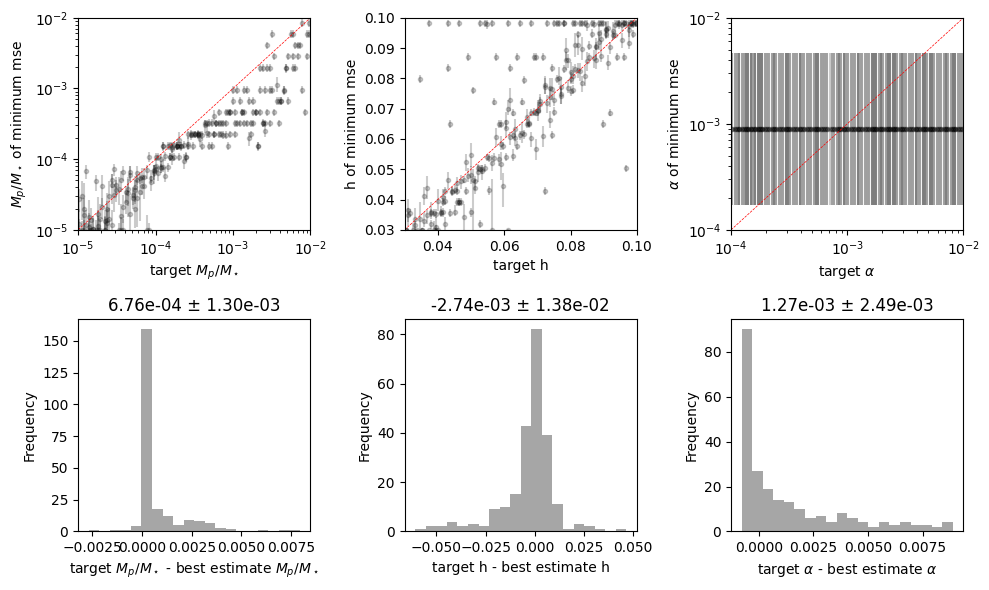

In [48]:
fig, axsb = plt.subplots(2, 3, figsize=(10,6))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb[0]
axs2 = axsb[1]
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])
    axs2[i].hist(err, bins=20, color='gray', alpha=0.7)
    axs2[i].set_xlabel(f'target {labels[para]} - best estimate {labels[para]}')
    axs2[i].set_ylabel('Frequency')
    axs2[i].set_title(f'{err.mean():.2e} ± {err.std():.2e}')

plt.tight_layout()
plt.savefig('MAIN_plots/fixed_emu_error_a2.png', dpi=500, bbox_inches='tight')

# With spatial correlation

In [ ]:
from tqdm import tqdm
all = {k: [] for k in emulationsa2_convolved.keys()}

for key in emulationsa2_convolved.keys():
    for i, sliceA in tqdm(enumerate(emulationsa2_convolved[key])):
        all2 = []
        for sliceB in sliceA:
            chi2 = 0.0
            for j, c in enumerate(sliceB):
                chi2 += get_chi2_from_convolved_rms(c-noisy_convolved_testset[i, j], kernel, rms)
            all2.append(chi2)
        all[key].append(all2)

233it [03:23,  1.14it/s]
233it [03:25,  1.13it/s]
233it [03:28,  1.12it/s]


In [ ]:

mse = {k: np.array(v) for k, v in all.items()}
from evaluation_lib import get_best_likeeqpost
vals = np.array(all)
grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}
#mse = {'PlanetMass': vals, 'Alpha': vals, 'AspectRatio': vals}
bestest, errs, sigmas = get_best_likeeqpost(None, None, sigma=1, mse=mse, grids=grids)

100%|██████████| 3/3 [00:00<00:00, 1103.67it/s]


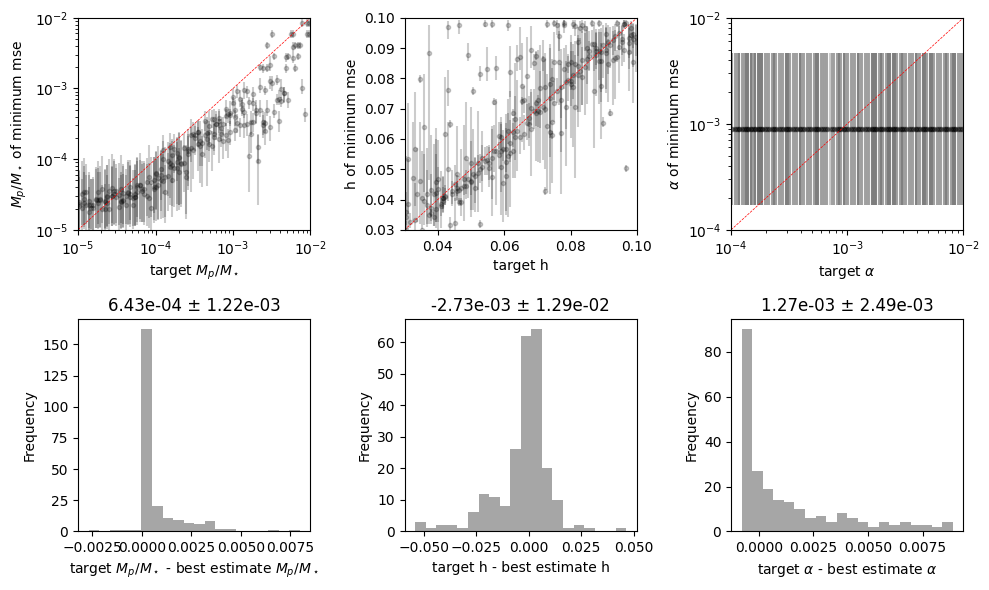

In [34]:
fig, axsb = plt.subplots(2, 3, figsize=(10,6))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb[0]
axs2 = axsb[1]
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])
    axs2[i].hist(err, bins=20, color='gray', alpha=0.7)
    axs2[i].set_xlabel(f'target {labels[para]} - best estimate {labels[para]}')
    axs2[i].set_ylabel('Frequency')
    axs2[i].set_title(f'{err.mean():.2e} ± {err.std():.2e}')

plt.tight_layout()
plt.savefig('MAIN_plots/spatial_corr_a2.png', dpi=500, bbox_inches='tight')

# Model error, linear relation, only where the emulator is not zero

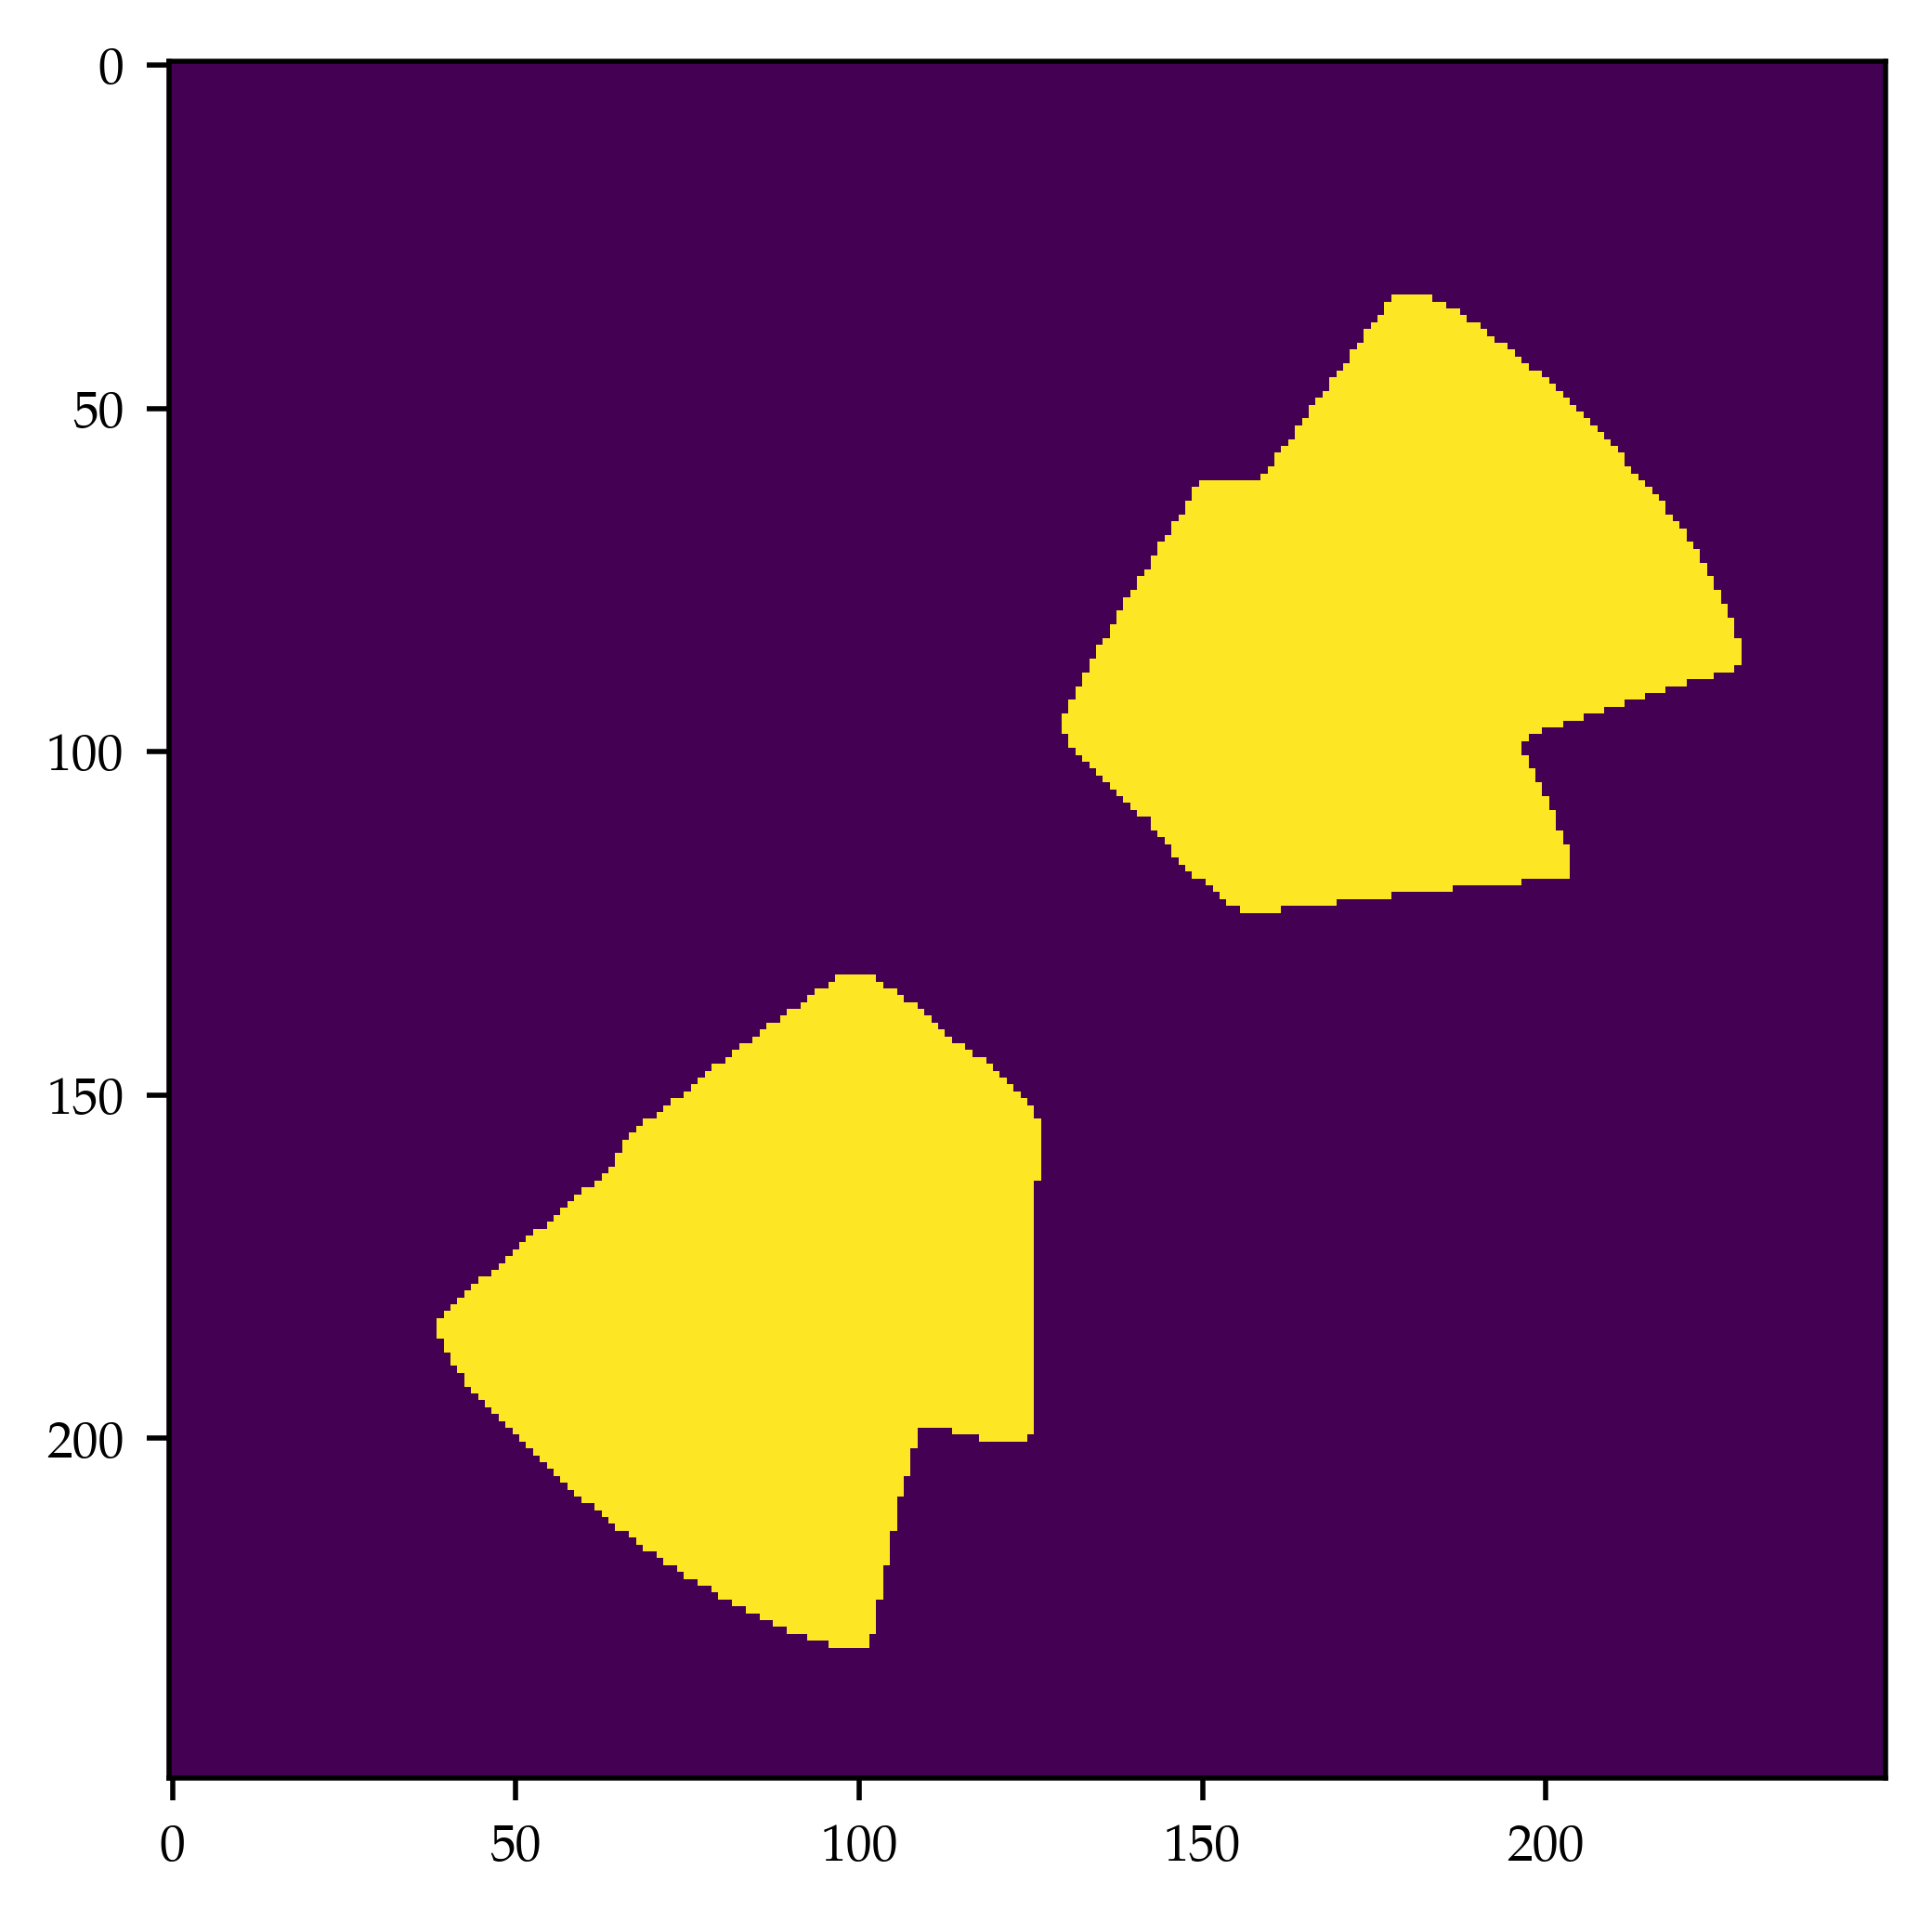

In [37]:
plt.imshow(emulationsa2_convolved['PlanetMass'][0,0,11]>1e-3)

In [49]:
from tqdm import tqdm
mses = {}
rms = 1.5e-3
for key in tqdm(mse_varp_testset.keys()):
    if key=='PlanetMass':
        sigmas = rms**2 + (emulationsa2_convolved[key]>1.5e-3).astype(int)*(10**(2*(np.linspace(-5,-2,20)*0.73-1.09))).reshape(1,-1,1,1,1)
    else:
        sigmas = rms**2 + (emulationsa2_convolved[key]>1.5e-3).astype(int)*np.array(10**(2*(np.log10(testparams['PlanetMass'])*0.73-1.09))).reshape(-1,1,1,1,1)
    #sum_factor = (emulations_convolved[key]!=0).sum(axis=(2,3,4))
    mses[key] = 0.5*((emulationsa2_convolved[key]-np.expand_dims(noisy_convolved_testset, axis=1))**2/sigmas).sum(axis=(2,3,4)) + (0.5*np.log(2*np.pi*sigmas)).sum(axis=(2,3,4))
np.save('msesa2_moderrmp_emunotzero.npy', mses)

100%|██████████| 3/3 [06:17<00:00, 125.98s/it]


In [39]:
#Compute best estimates and errors from the mse curves
#only vr
from evaluation_lib import get_best_likeeqpost
grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}
bestest, errs, sigmas = get_best_likeeqpost(None, None, sigma=1, mse=mses, grids=grids)

100%|██████████| 3/3 [00:00<00:00, 928.08it/s]


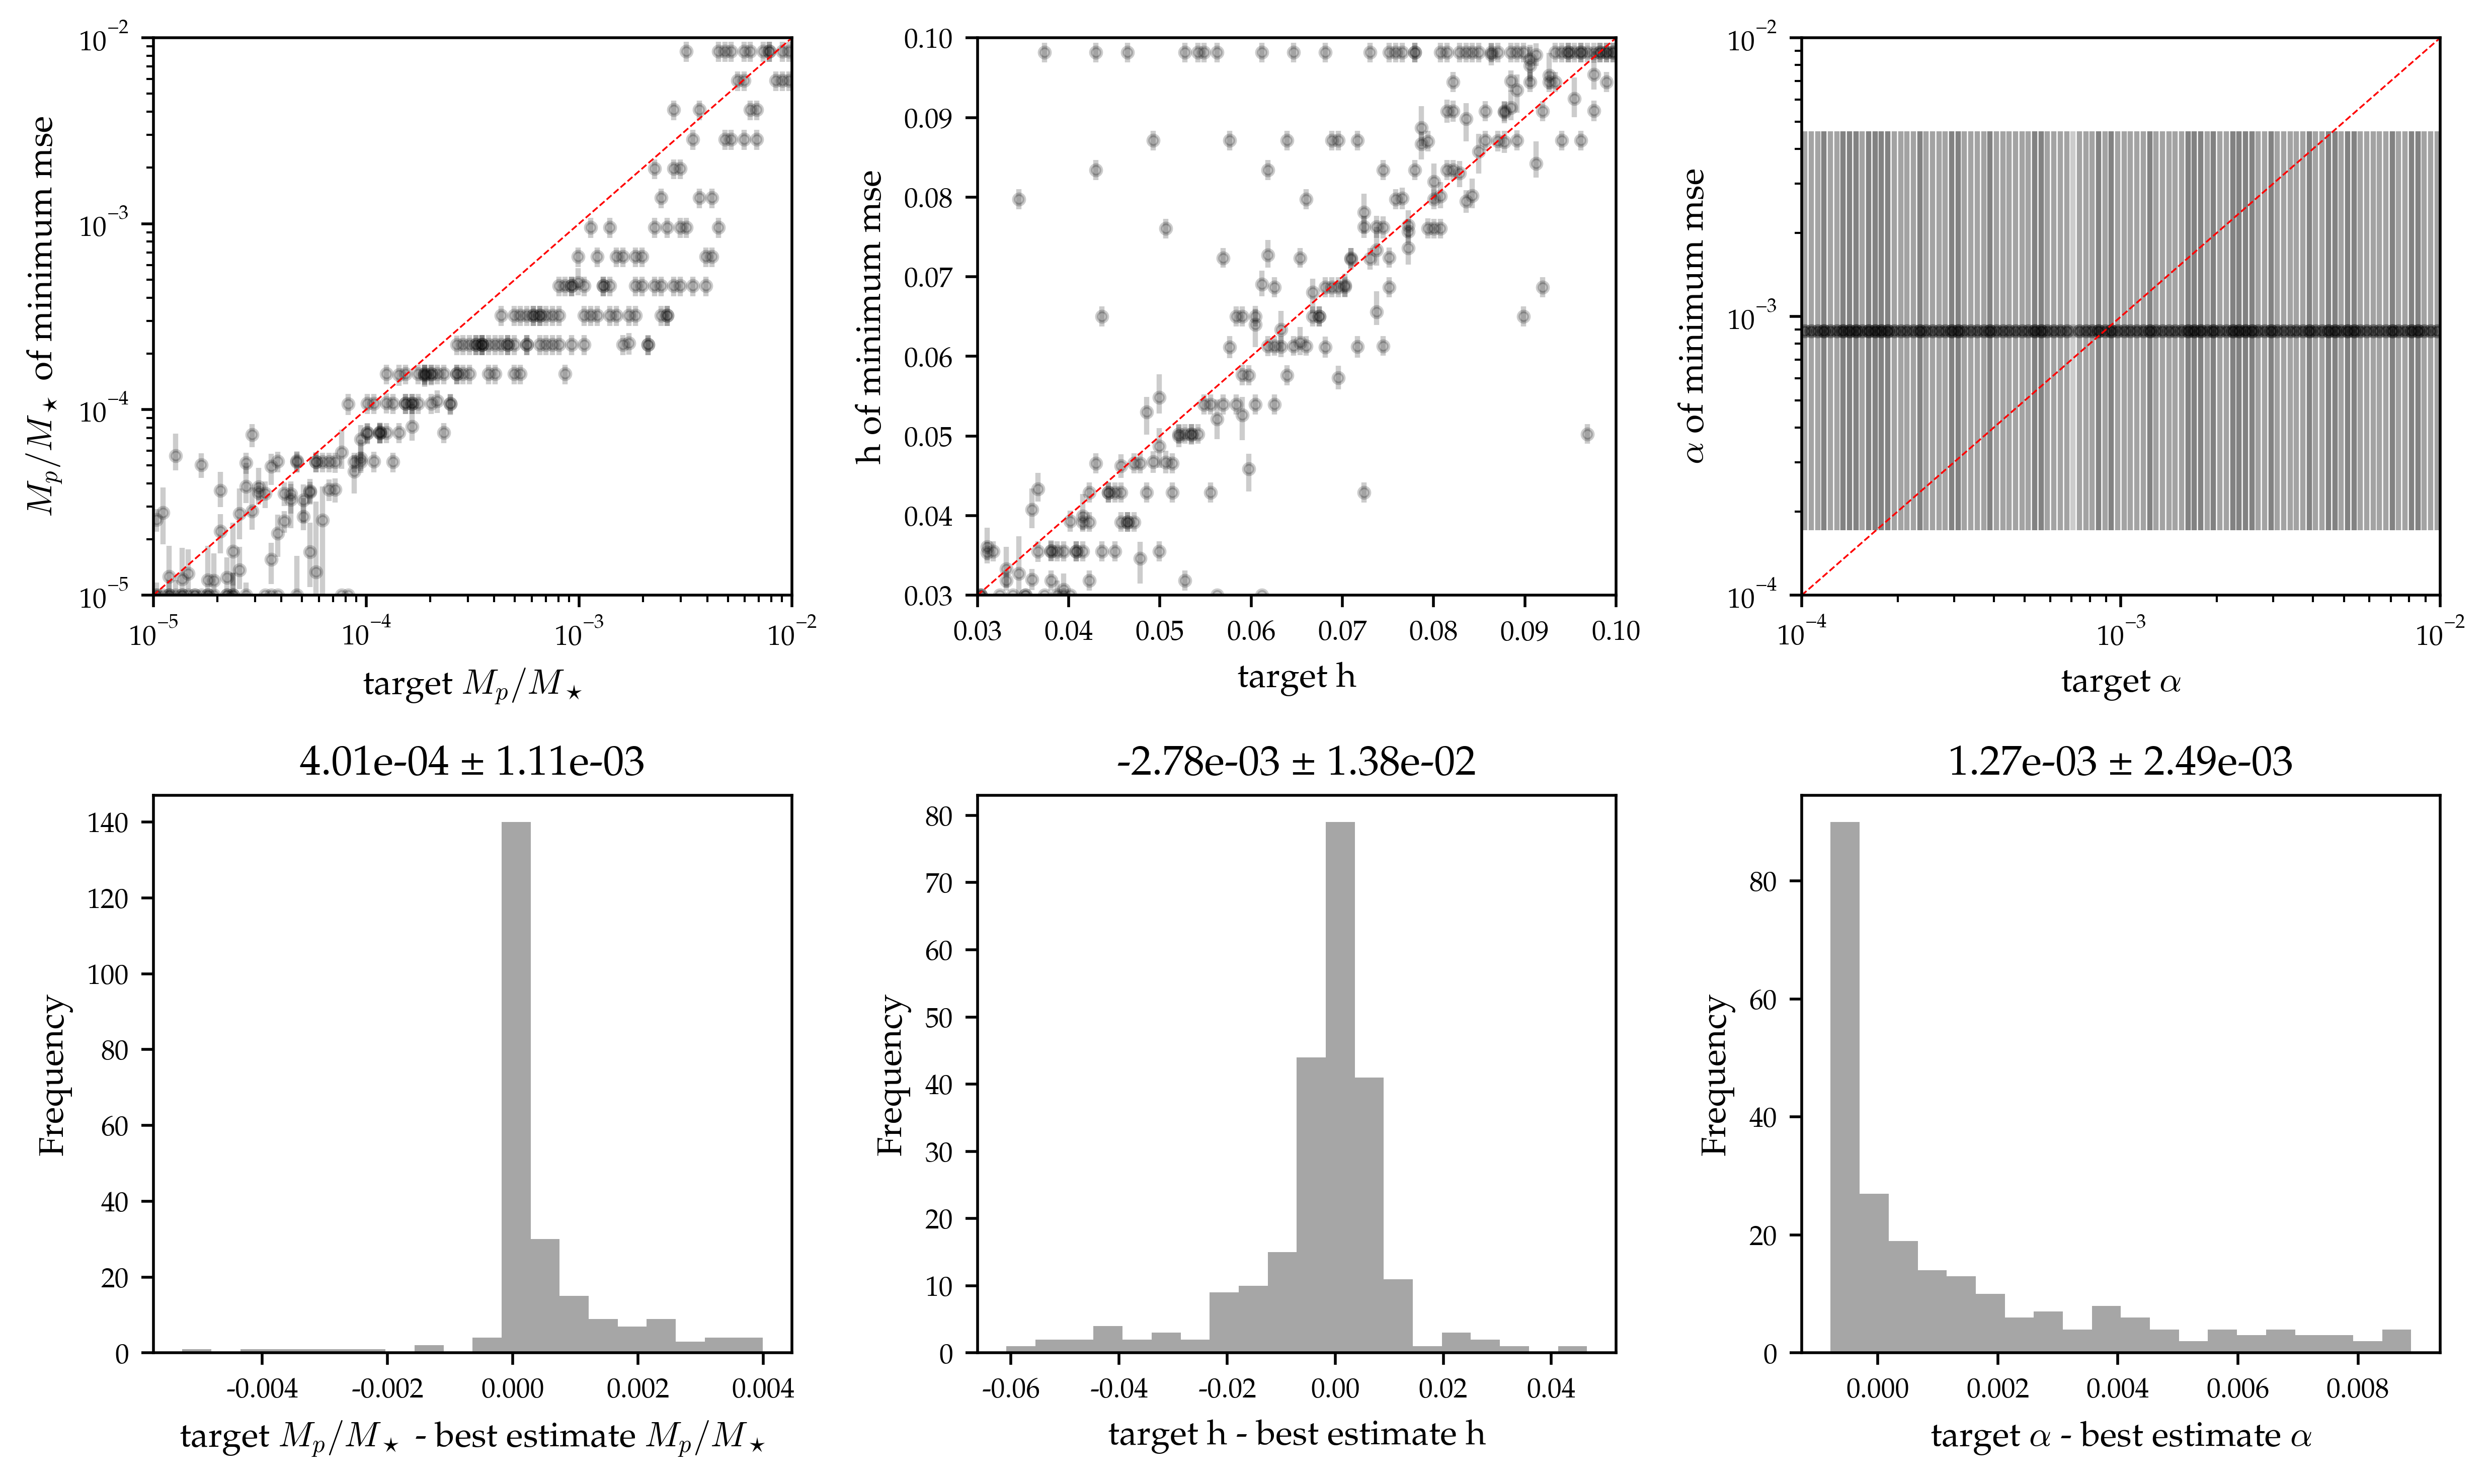

In [50]:
fig, axsb = plt.subplots(2, 3, figsize=(10,6))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb[0]
axs2 = axsb[1]
for i, para in enumerate(['PlanetMass', 'AspectRatio', 'Alpha']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])
    axs2[i].hist(err, bins=20, color='gray', alpha=0.7)
    axs2[i].set_xlabel(f'target {labels[para]} - best estimate {labels[para]}')
    axs2[i].set_ylabel('Frequency')
    axs2[i].set_title(f'{err.mean():.2e} ± {err.std():.2e}')

plt.tight_layout()
plt.savefig('MAIN_plots/depending_on_mp_a2.png', dpi=500, bbox_inches='tight')

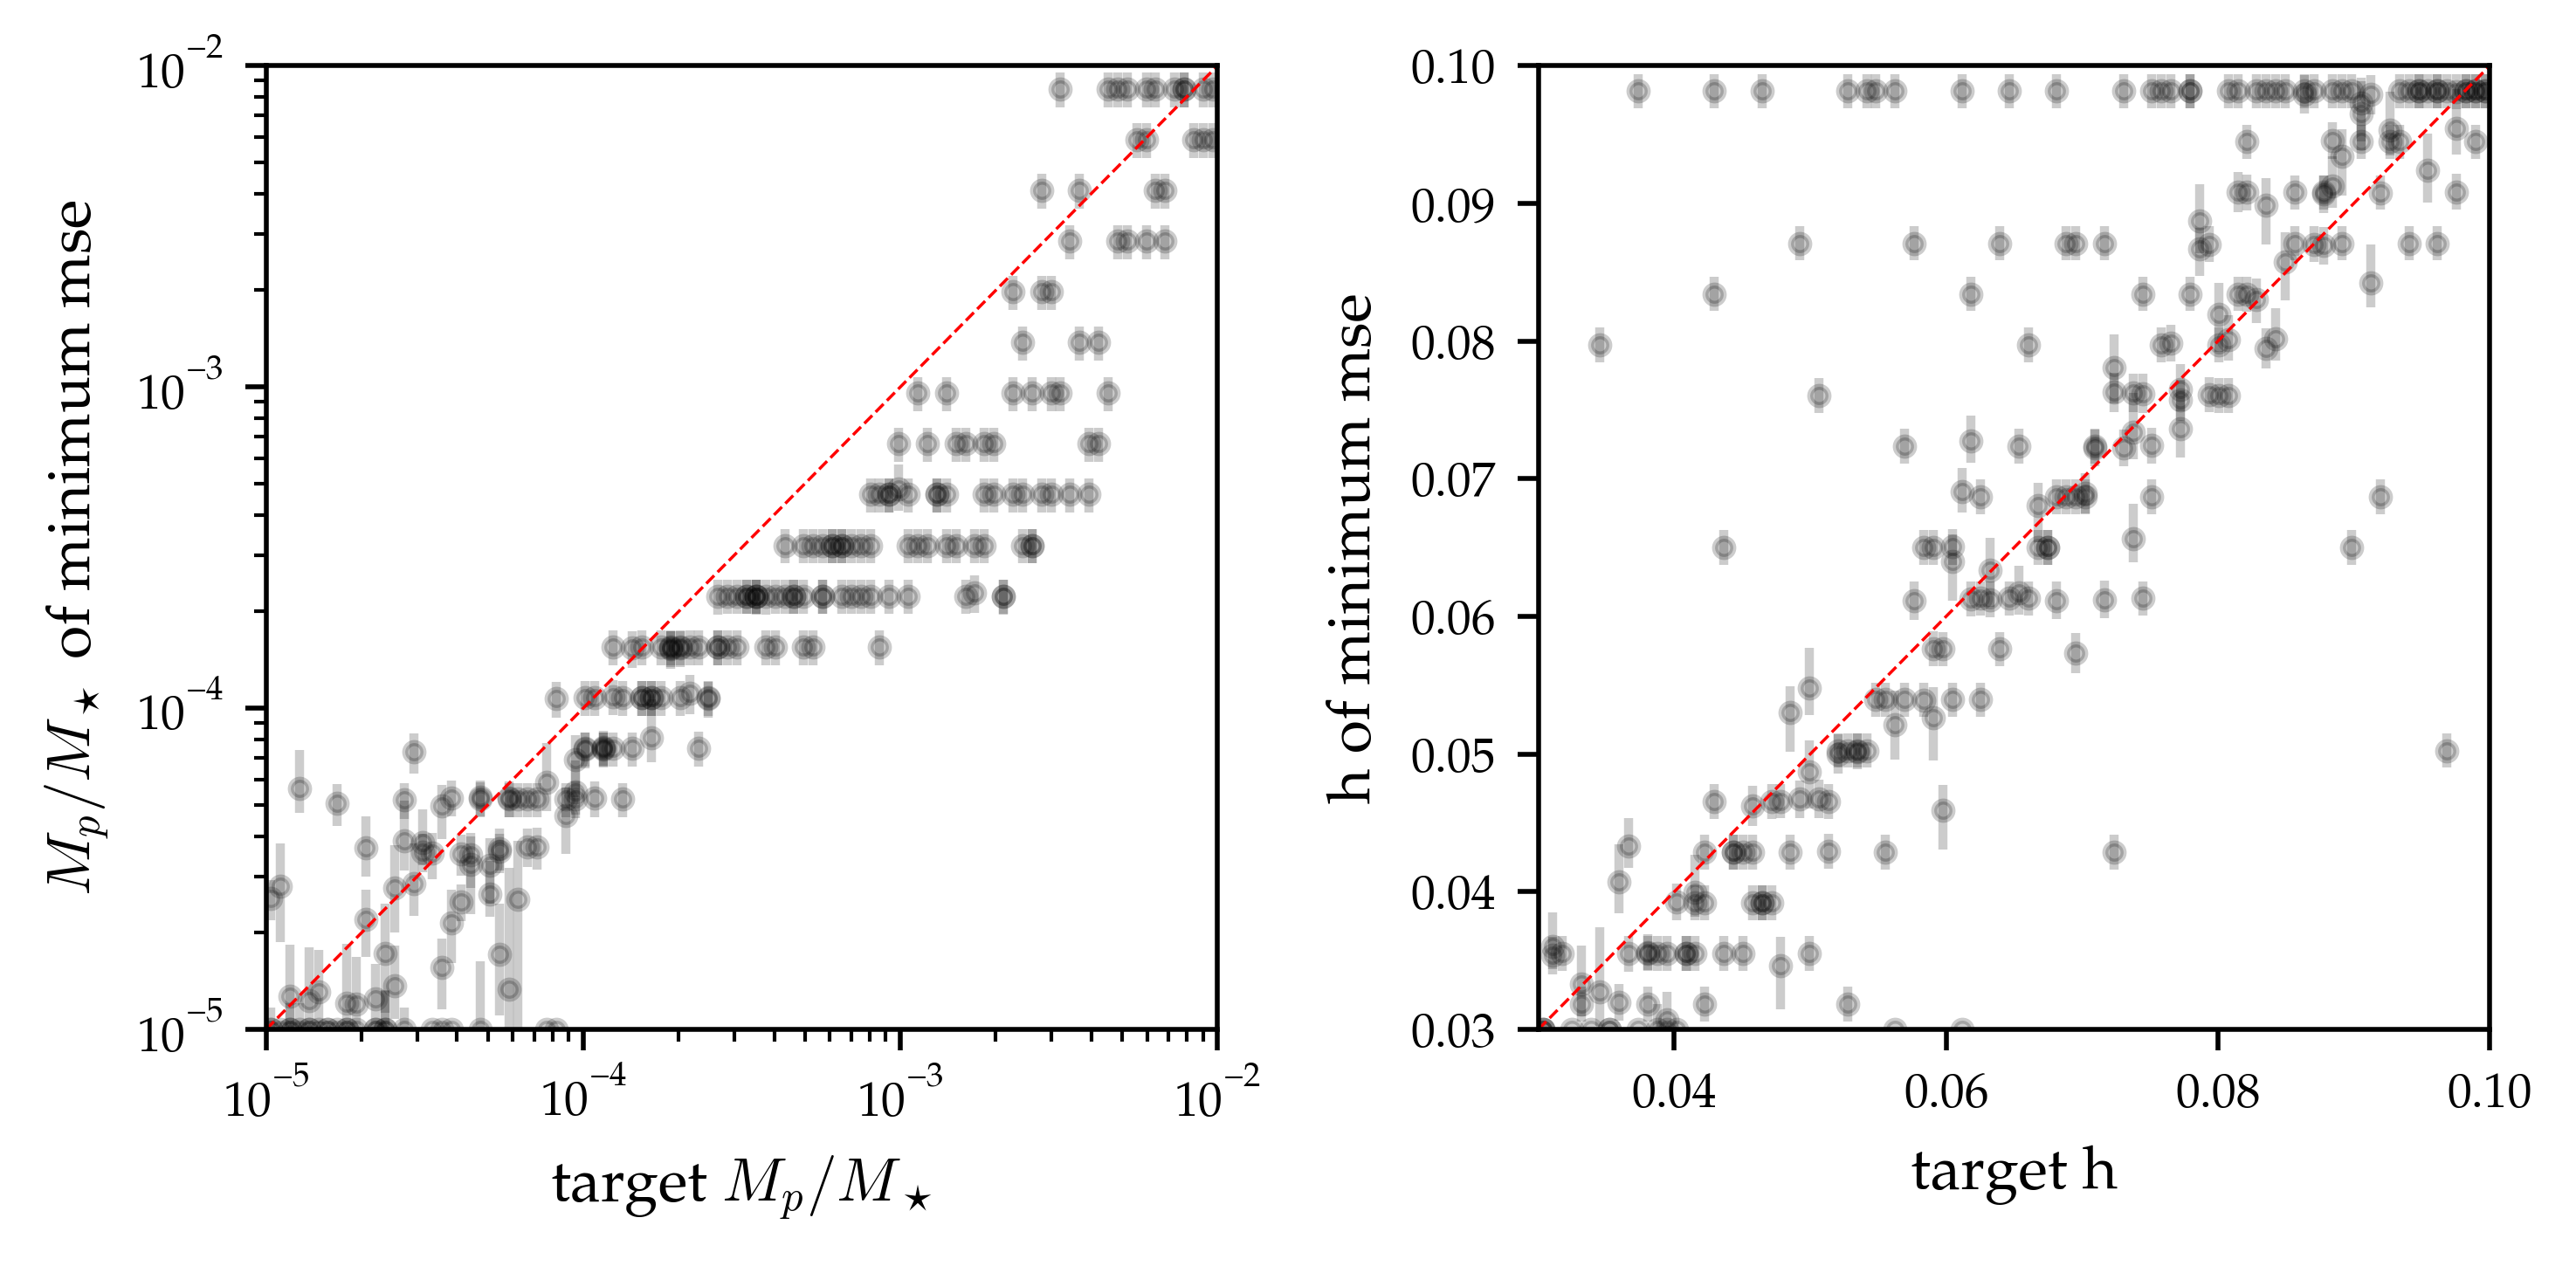

In [52]:
fig, axsb = plt.subplots(1, 2, figsize=(6,3))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2), 'thmass': (1e-2,2e2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$', 'thmass': '$M_p/M_\\text{th}$'}

testparams['thmass'] = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
bestest['thmass'] = 3*bestest['PlanetMass']/(2*testparams['AspectRatio']**3)
errs['thmass'] = 3*np.array(errs['PlanetMass'])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3)

axs = axsb
for i, para in enumerate(['PlanetMass', 'AspectRatio']):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

    err = (testparams[para]-bestest[para])

plt.tight_layout()
plt.savefig('MAIN_plots/depending_on_mp_a2_simple.pdf', dpi=500, bbox_inches='tight')

# OLD --- Test computation of error bars


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# Convert everything to arrays first
emu = np.array(emulations_convolved['PlanetMass'])  # shape (nA, nB, nchan, Ny, Nx)
ref = noisy_convolved_testset                        # shape (nA, nchan, Ny, Nx)

# Residuals: broadcast ref over nB axis
residuals = emu - ref[:, np.newaxis, :, :, :]        # (nA, nB, nchan, Ny, Nx)

# Batch FFT over spatial axes
Fr = fft2(residuals, s=pad_shape, workers=-1, axes=(-2,-1))
Finv_Sigma_r = Fr / FBcov_reg                        # FBcov_reg: (pad_Ny, pad_Nx) broadcasts
inv_Sigma_r = np.real(ifft2(Finv_Sigma_r, workers=-1, axes=(-2,-1)))[..., :Ny, :Nx]

# Sum over spatial and channel axes
all_chi2 = np.sum(residuals * inv_Sigma_r, axis=(-3,-2,-1))  # (nA, nB)
all = all_chi2.tolist()
rangelen = {'PlanetMass': 3, 'AspectRatio': 0.07, 'Alpha': 2}
params = ['PlanetMass', 'AspectRatio', 'Alpha']
grids = {'Alpha': np.logspace(-4,-2,20),
                 'PlanetMass': np.logspace(-5,-2,20),
                 'AspectRatio': np.linspace(0.03, 0.1,20)}
sigma = 10*rms

bestest = {}
sigmas = {}
valmins = {}
errs = {}
mse = {}

print('Computing things...')
for para in params:
    mse[para] = ((emulations[para]-np.expand_dims(noisy_testset, axis=1))**2/(2*sigma**2)).sum(axis=(-1,-2,-3))

NameError: name 'rms' is not defined

In [ ]:
def get_best_likeeqpost(emulations, testset, sigma):
    bestest = {}
    sigmas = {}
    valmins = {}
    errs = {}
    mse = {}
    like = {}
    perc = {}

    print('Computing things...')
    for para in params:
        mse[para] = ((emulations[para]-np.expand_dims(testset, axis=1))**2/(2*sigma**2)).sum(axis=(-1,-2,-3))
        like[para] = np.exp(-(mse[para]-np.min(mse[para], axis=1).reshape(-1,1)))
        perc[para] = np.cumulative_sum(like[para], axis=1)/np.sum(like[para], axis=1).reshape(-1,1)        
        
    for para in tqdm(['PlanetMass', 'AspectRatio', 'Alpha']):
        sigmas_l = []
        sigmas_r = []
        bestest[para] = []
        for i in range(emulations[para].shape[0]):
            sl, med, sr = np.interp([0.16,0.5, 0.84], perc[para][i], grids[para])
            sigmas_l.append(med-sl)
            sigmas_r.append(sr-med)
            bestest[para].append(med)
        sigmas[para] = np.array([sigmas_l, sigmas_r])
        bestest[para] = np.array(bestest[para])
        
    return bestest, sigmas, sigmas

In [60]:
bestest, errs, sigmas = get_best_likeeqpost(emulationsa2, noisy_testset, sigma=rms)

Computing things...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 114.39it/s]


In [29]:
emulations = emulations_convolved
testset = noisy_convolved_testset
sigma = 1e-1
bestest = {}
sigmas = {}
valmins = {}
errs = {}
mse = {}
like = {}
perc = {}

print('Computing things...')
for para in params:
    mse[para] = ((emulations[para]-np.expand_dims(testset, axis=1))**2/(2*sigma**2)).sum(axis=(-1,-2,-3))
    like[para] = np.exp(-(mse[para]-np.min(mse[para], axis=1).reshape(-1,1)))
    perc[para] = np.cumulative_sum(like[para], axis=1)/np.sum(like[para], axis=1).reshape(-1,1)       

Computing things...


### curves


In [30]:
mse[para].shape

(233, 20)

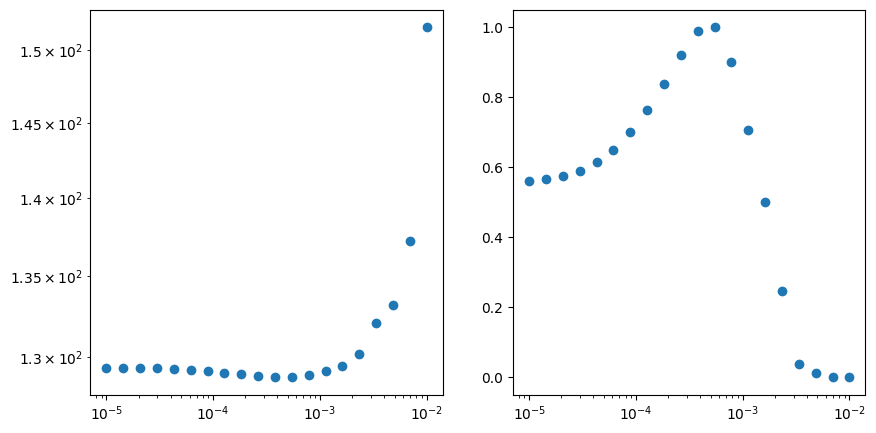

In [31]:
i=19
para = 'PlanetMass'

fig, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].scatter(grids[para], mse[para][i])
axs[1].scatter(grids[para], like[para][i])
axs[0].set_yscale('log')
#axs[0].set_ylim(50,200)
for j in (0,1):
    axs[j].set_xscale('log')

In [32]:
plt.errorbar(testparams['PlanetMass'], bestest['PlanetMass'], yerr=sigmas['PlanetMass'], fmt='.')
plt.xscale('log')
plt.yscale('log')
plt.plot([1e-5, 1e-2], [1e-5, 1e-2])

KeyError: 'PlanetMass'

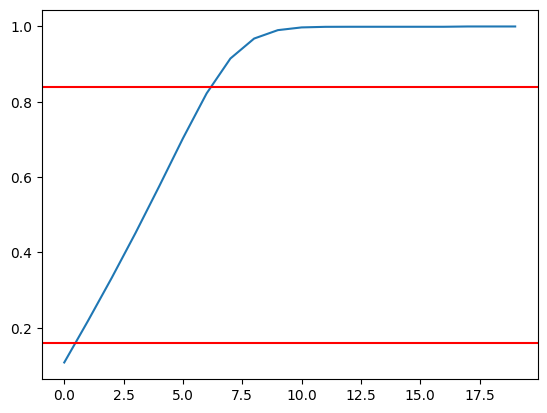

In [33]:
id = 158
val = (1-mse['PlanetMass'][id]/np.sum(mse['PlanetMass'][id]))/np.sum(1-mse['PlanetMass'][id]/np.sum(mse['PlanetMass'][id]))
val = np.exp(-(mse['PlanetMass'][id]-np.min(mse['PlanetMass'][id])))
plt.plot(np.cumulative_sum(val)/np.sum(val))
plt.axhline(0.84, color='red')
plt.axhline(0.16, color='red')

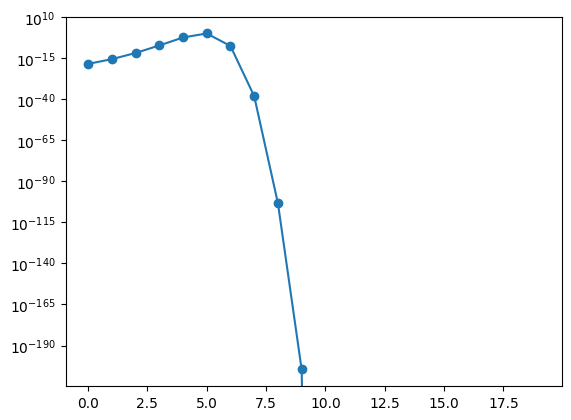

In [49]:
id= 158
plt.plot(np.exp(-(mse['PlanetMass'][id]-np.min(mse['PlanetMass'][id]))), marker='o')
plt.yscale('log')

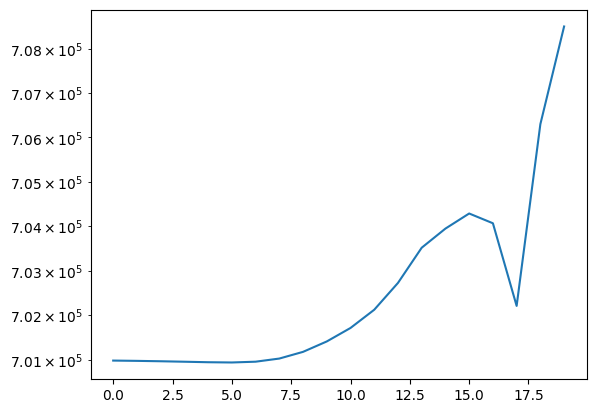

In [48]:
plt.plot(mse['PlanetMass'][158])
plt.yscale('log')

In [97]:
np.sqrt(22*250*250)

np.float64(1172.6039399558574)

# Plots for presentation

100%|███████████████████████████████████████████| 22/22 [00:00<00:00, 52.77it/s]


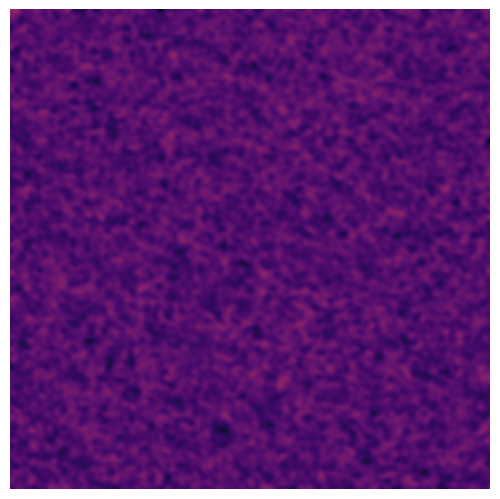

In [61]:
import imageio.v2 as imageio

frames = []

fig, ax = plt.subplots()
fig.subplots_adjust(0, 0, 1, 1)

for i in tqdm(range(noisy_convolved_testset.shape[1])):
    ax.clear()
    ax.imshow(
        noisy_convolved_testset[refid, i],
        vmax=vmax,
        vmin=vmin,
        cmap='inferno'
    )
    ax.axis('off')

    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba()).copy()  # <-- IMPORTANT
    frames.append(frame)

imageio.mimsave(
    f"gif{refid}.gif",
    frames,
    duration=300,
    loop=0
)

In [64]:
emulations_convolved['PlanetMass'].shape

(233, 20, 22, 250, 250)

In [136]:
rms = 1.4e-2
sigma=rms
para = 'PlanetMass'
mse = ((emulations_convolved[para]-np.expand_dims(noisy_convolved_testset, axis=1))**2/(2*sigma**2)).sum(axis=(-1,-2,-3))
like = {}
perc = {}
for para in ['PlanetMass']:
    like[para] = np.exp(-1*(mse-np.min(mse, axis=1).reshape(-1,1)))
    like[para] /= np.sum(like[para], axis=-1).reshape(-1,1)    
    perc[para] = np.cumulative_sum(like[para], axis=-1)/np.sum(like[para], axis=-1).reshape(-1,1)    

In [137]:
like[para].shape

(233, 20)

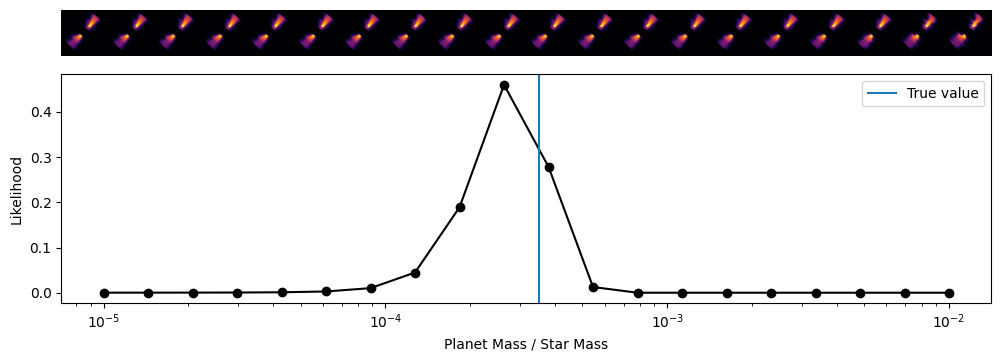

In [140]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# example data
x = np.arange(20)

refid=85

images = emulations_convolved['PlanetMass'][refid][:, 10]   # shape: (20, H, W)

fig = plt.figure(figsize=(12, 4))
gs = GridSpec(
    2, 20,
    height_ratios=[1, 3],   # big plot + small images
    hspace=0.02,
    wspace=0.0
)

# --- top plot (span all columns)
ax_plot = fig.add_subplot(gs[1, :])
ax_plot.plot(np.logspace(-5,-2,20), like[para][refid], marker='o', color='black')
ax_plot.set_xticks(np.logspace(-5,-2,20))
ax_plot.set_xscale('log')# remove ticks (images replace them)
ax_plot.set_xlabel('Planet Mass / Star Mass')
ax_plot.set_ylabel('Likelihood')
ax_plot.axvline(testparams['PlanetMass'].iloc[refid], label='True value')
ax_plot.legend()
# --- bottom images
for i in range(20):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(images[i], cmap='inferno')
    ax.axis("off")

plt.savefig('PlotTest.png', dpi=500, bbox_inches='tight')

In [146]:
import h5py
emulations_cmaps = h5py.File("cmaps_emulations_small_SIMPARAN.h5", "r", swmr=True)
emulations_cmaps['emu_true_para'].refresh()

In [145]:
emulations_cmaps.close()

In [97]:

testset_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like3corr.npy')
testset = testset_cmaps[:, 42:64] #only the central channels are present in the testset map

In [98]:
# convolution
#convolve 
import astropy.units as u
from astropy.convolution import Gaussian2DKernel

#Note that angles should be rechecked if changing the beam

Rmax = 380 * u.au
npix = 250
dpc = 101.5 * u.pc
beam_size_mas_amaj = 104 * u.mas
beam_size_mas_amin = 94 * u.mas
beam_size_pa = 90-80.2 #deg

dpix = np.arctan((Rmax.to('au') / (0.5*(npix-1))) / dpc.to('pc')).to(u.deg)

sigma_maj_pix = beam_size_mas_amaj/dpix / 2.35
sigma_min_pix = beam_size_mas_amin/dpix / 2.35

kernel = Gaussian2DKernel( sigma_maj_pix, sigma_min_pix, beam_size_pa)

In [29]:
sigma_min_pix.to('')

<Quantity 1.33018421>

In [32]:
from scipy.ndimage import convolve
rms = 6.2e-3 #Jy/px -> same as Pinte+2018 observation
noise = np.random.normal(0, rms, testset.shape)
noisy_testset = noise+testset

noisy_convolved_testset = convolve(noisy_testset, kernel, axes=(-1,-2))

In [153]:
convolved_emulations = convolve(emulations_cmaps['emu_true_para'], kernel, axes=(-1,-2))

In [206]:
convolved_noise = convolve(noise, kernel, axes=(-1,-2))

In [192]:
expected_rms = np.sqrt(rms**2*np.sum(np.ravel(kernel)**2))

In [193]:
expected_rms

<Quantity 0.00125004>

In [122]:
emulations_cmaps['emu_true_para'].shape

(233, 22, 250, 250)

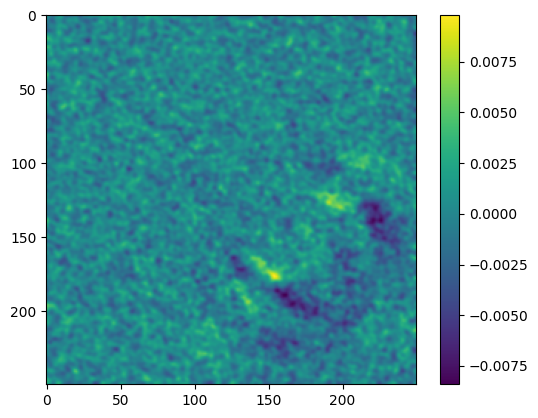

In [168]:
plt.imshow(noisy_convolved_testset[232, 14]-convolved_emulations[33, 14])
plt.colorbar()

In [172]:
err = (noisy_convolved_testset-convolved_emulations)

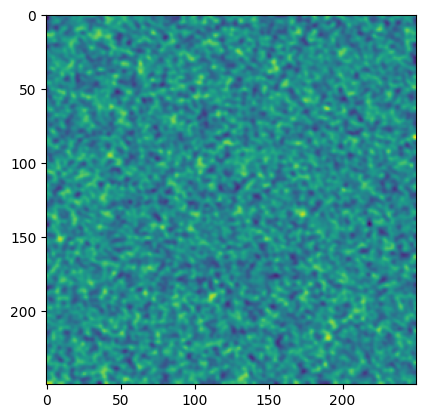

In [211]:
plt.imshow(convolved_noise[0,0])

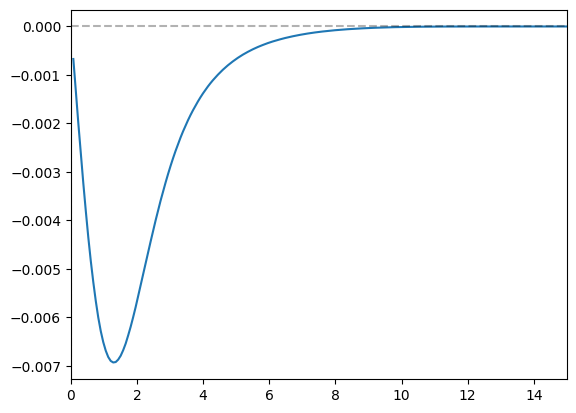

In [213]:
from scipy.stats import norm

erra = np.abs(err.ravel())
valb, bins = np.histogram(erra/expected_rms, bins=np.linspace(0, 15, 200))
valb = np.cumsum(valb/len(erra))

noisecum, bins2 = np.histogram(np.abs(convolved_noise.ravel())/expected_rms, bins=np.linspace(0, 15, 200))
noisecum = np.cumsum(noisecum/len(convolved_noise.ravel()))

p = (norm.cdf(bins[1:])-0.5)*2

plt.plot(bins[1:], valb-noisecum)
plt.xlim(0,15)
plt.axvline(0, color='black', alpha=0.3, linestyle='dashed')
plt.axhline(0, color='black', alpha=0.3, linestyle='dashed')

In [139]:
emulations_cmaps['emu_true_para'].refresh()
emu = emulations_cmaps['emu_true_para']

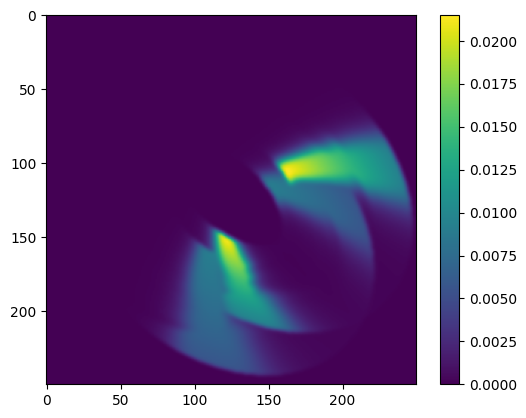

In [154]:
plt.imshow(convolved_emulations[232, 13])
plt.colorbar()